In [1]:
#use wdtools_env_pip environment 

import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy import stats
from tqdm import tqdm

import pandas as pd
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Suppress SettingWithCopyWarnings
pd.options.mode.chained_assignment = None  # default='warn'

#for multiprocessing
from joblib import Parallel, delayed

#to import SDSS-V data
import fsspec
import requests
import aiohttp
from astropy.io import fits

#manually import from the wdtools .py files
#this is my edited version of wdtools in which the PRF routine can handle fitting higher order lines
import sys
import os
sys.path.append('../Software')
from wdtools_nicole.parametric import LineProfiles


In [2]:
#input SDSS-V username and password
file=open('SDSSVlogin.txt')
content = file.readlines()
username=content[0][:len(content[0])-1] #remove the \n
password=content[1]

# This notebook measures the DA WD spectroscopic Teffs and Loggs using WDtools

# Train the wdtools PRF routine on higher order lines

### Download the original training set of Tremblay 2019 parameters and the corresponding SDSS spectra
- https://cdsarc.cds.unistra.fr/viz-bin/cat/J/MNRAS/482/5222#/browse

In [3]:
#read in the data
tremblay_training1= pd.read_csv('data/wdtools_training/J_MNRAS_482_5222_tablea1.dat.txt',sep='|')
tremblay_training2= pd.read_csv('data/wdtools_training/J_MNRAS_482_5222_tablea2.dat.gz.txt',sep='|')
#drop the first row of dashes and the last row of NaNs
tremblay_training1=tremblay_training1.drop(0)
tremblay_training1=tremblay_training1.drop(len(tremblay_training1))
tremblay_training2=tremblay_training2.drop(0)
tremblay_training2=tremblay_training2.drop(len(tremblay_training2))
#combine the dataframes
tremblay_training=pd.concat([tremblay_training1, tremblay_training2], ignore_index=True)
#remove spaces from column names
tremblay_training.columns=tremblay_training.columns.str.replace(' ', '')
#convert all relevant columns to numeric values
tremblay_training['Teff']=pd.to_numeric(tremblay_training['Teff'])
tremblay_training['e_Teff']=pd.to_numeric(tremblay_training['e_Teff'])
tremblay_training['logg']=pd.to_numeric(tremblay_training['logg'])
tremblay_training['e_logg']=pd.to_numeric(tremblay_training['e_logg'])
#rename columns
tremblay_training=tremblay_training.rename(columns={"Teff": "teff", "e_Teff": "e_teff"})
#turn pmf into columns
plates=[]
mjds=[]
fibers=[]
for pmf in tremblay_training['MPF'].to_list():
    mjd,plate,fiber=pmf.split('-')
    plates.append(plate)
    mjds.append(mjd)
    fibers.append(fiber)
tremblay_training['plate']=plates
tremblay_training['mjd']=mjds
tremblay_training['fiber']=fibers
#add unique PMF identifyer
tremblay_training['pmf']=tremblay_training['plate'].astype(str)+tremblay_training['mjd'].astype(str)+tremblay_training['fiber'].astype(str)
tremblay_training['pmf']=tremblay_training['pmf'].astype(int)

In [5]:
#break into sets of ~500 observations
num_tables=int(len(tremblay_training)/500)+1
print(num_tables)

tab_dict={}
for i in tqdm(range(num_tables)):
    tab_dict['set_'+str(i)]=tremblay_training[500*i:500*i+500]
    #reset the indices
    indices=np.arange(0,len(tab_dict['set_'+str(i)]))
    tab_dict['set_'+str(i)].set_index(indices,inplace=True)

12


100%|█████████████████████████████████████████| 12/12 [00:00<00:00, 8280.96it/s]


In [9]:
def parallelprocess_get_spectra(i):
    #get SDSS spectra
    
    urls=['https://dr18.sdss.org/sas/dr18/spectro/sdss/redux/26/spectra/lite/',
          'https://dr18.sdss.org/sas/dr18/spectro/sdss/redux/103/spectra/lite/',
          'https://dr18.sdss.org/sas/dr18/spectro/sdss/redux/104/spectra/lite/',
          'https://dr18.sdss.org/sas/dr18/spectro/sdss/redux/v5_13_2/spectra/lite/',
          'https://dr18.sdss.org/sas/dr18/spectro/sdss/redux/v6_0_4/spectra/lite/',
         'https://dr18.sdss.org/sas/dr18/spectro/sdss/redux/eFEDS/spectra/lite/',
         'https://dr18.sdss.org/sas/dr18/spectro/boss/redux/eFEDS/spectra/lite/',
         'https://dr18.sdss.org/sas/dr18/spectro/boss/redux/v6_0_4/spectra/lite/']
    
    snrs=[]
    spec_flags=[]
    for j in range(len(tab_dict['set_'+str(i)])):
        tmp=tab_dict['set_'+str(i)].loc[j]
        plate=str(tmp['plate'])
        if len(plate)<4:
            plate='0'+plate
        mjd=str(tmp['mjd'])
        fiber=str(tmp['fiber'])
        if len(fiber)==1:
            fiber='000'+fiber
        if len(fiber)==2:
            fiber='00'+fiber
        if len(fiber)==3:
            fiber='0'+fiber
        filename=str(tmp['pmf'])
        fitsfilename='spec-'+plate+'-'+mjd+'-'+fiber+'.fits'

        for k in range(len(urls)):
            base_url=urls[k]
            found_spec=False
            try:
                url=base_url+plate+'/'+fitsfilename 
                with fits.open(url) as spec:
                    # Get pertinent spectrum data    
                    wavl = np.array(10**spec[1].data['loglam'])
                    flux = np.array(spec[1].data['flux'])
                    ivar = np.array(spec[1].data['ivar'])
                    snr=np.array(spec[2].data['SN_MEDIAN_ALL'][0])
                #write the data in a txt file
                np.savez('data/wdtools_training/SDSS_spectra/'+filename,flux=flux,wavl=wavl,ivar=ivar,snr=snr)
                snrs.append(snr)
                spec_flags.append(k)
                found_spec=True
                break
            except:
                continue
        
        if found_spec==False:
            snrs.append(np.nan)
            spec_flags.append(np.nan)
            
    tab_dict['set_'+str(i)]['snr']=snrs
    tab_dict['set_'+str(i)]['spec_avail']=spec_flags
    #save the short sets
    tab_dict['set_'+str(i)].to_csv('data/wdtools_training/short_sets/'+str(i)+'.csv',index=False)
    

In [10]:
#get spectra
try:
    os.makedirs('data/wdtools_training/SDSS_spectra')
    os.makedirs('data/wdtools_training/short_sets')
except:
    pass

print(num_tables)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_get_spectra)(i) for i in range(num_tables))

12


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=-2)]: Done   1 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-2)]: Done   3 out of  12 | elapsed:   15.7s remaining:   47.2s
[Parallel(n_jobs=-2)]: Done   5 out of  12 | elapsed:   18.0s remaining:   25.2s
[Parallel(n_jobs=-2)]: Done   7 out of  12 | elapsed:  5.8min remaining:  4.2min
[Parallel(n_jobs=-2)]: Done   9 out of  12 | elapsed:  7.2min remaining:  2.4min
[Parallel(n_jobs=-2)]: Done  12 out of  12 | elapsed:  7.4min finished


In [11]:
#read back in those tables
tab_dict={}
for i in tqdm(range(num_tables)):
    tab_dict['set_'+str(i)]=pd.read_csv('data/wdtools_training/short_sets/'+str(i)+'.csv')
    

100%|██████████████████████████████████████████| 12/12 [00:00<00:00, 260.44it/s]


In [12]:
#combine all of the dfs into one df
tremblay_training=pd.concat([tab_dict['set_0'], tab_dict['set_1']], ignore_index=True)
for i in range(num_tables-2):
    tremblay_training=pd.concat([tremblay_training, tab_dict['set_'+str(i+2)]], ignore_index=True)
#save the results of searching for spectra
tremblay_training.to_csv('data/wdtools_training/tremblay_training_set.csv',index=False)


In [13]:
#check for objects without spectra
nan_mask=tremblay_training['snr'].isnull()
nan_tab=tremblay_training[nan_mask]
#reset the indices
indices=np.arange(0,len(nan_tab))
nan_tab.set_index(indices,inplace=True)
display(nan_tab)

,Name,MPF,plx,e_plx,teff,e_teff,logg,e_logg,plxsp,e_plxsp,Comment,plate,mjd,fiber,pmf,snr,spec_avail,a_amp,a_center,a_sigma,a_gamma,a_fwhm,a_height,b_amp,b_center,b_sigma,b_gamma,b_fwhm,b_height,g_amp,g_center,g_sigma,g_gamma,g_fwhm,g_height,d_amp,d_center,d_sigma,d_gamma,d_fwhm,d_height,e_amp,e_center,e_sigma,e_gamma,e_fwhm,e_height,z_amp,z_center,z_sigma,z_gamma,z_fwhm,z_height,n_amp,n_center,n_sigma,n_gamma,n_fwhm,n_height,t_amp,t_center,t_sigma,t_gamma,t_fwhm,t_height


### Fit the line profiles of all 8 lines

In [14]:
def fit_voigt(wd_table,plot=False):
    #this function fits a voigt model to each line in a SDSS spectrum of a DA WD
    
    #initialize LineProfiles to fit all lines with the fit_balmer method
    lpfit = LineProfiles(fit_profiles=True,lines = ['alpha', 'beta', 'gamma', 'delta','epsilon','zeta','neta','theta'])
    
    # Suppress SettingWithCopyWarnings
    pd.options.mode.chained_assignment = None
    
    #initialize columns
    cols=['a_amp','a_center','a_sigma','a_gamma','a_fwhm','a_height','b_amp','b_center','b_sigma','b_gamma',
        'b_fwhm','b_height','g_amp','g_center','g_sigma','g_gamma','g_fwhm','g_height','d_amp','d_center','d_sigma',
        'd_gamma','d_fwhm','d_height','e_amp','e_center','e_sigma','e_gamma','e_fwhm','e_height','z_amp','z_center',
        'z_sigma','z_gamma','z_fwhm','z_height','n_amp','n_center','n_sigma','n_gamma','n_fwhm','n_height','t_amp',
        't_center','t_sigma','t_gamma','t_fwhm','t_height']
    for col in cols:
        wd_table[col]=np.full(len(wd_table),np.nan)
    
    for ind in range(len(wd_table)):
        plate=wd_table['plate'].loc[ind]
        mjd=wd_table['mjd'].loc[ind]
        fiber=wd_table['fiber'].loc[ind]   
        filename=str(wd_table['pmf'].loc[ind])
        #Get pertinent spectrum data 
        npzfile = np.load('data/wdtools_training/SDSS_spectra/'+filename+'.npz')
        wl = npzfile['wavl'] #wavelength in angstroms
        fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
        #fit the lines with Voigt profiles
        result=lpfit.fit_balmer(wl, fl, make_plot = plot)
        #add fit results to the dataframe
        for col in cols:
            value=result[col].to_list()[0]
            wd_table[col].loc[ind]=value
            
    return(wd_table)

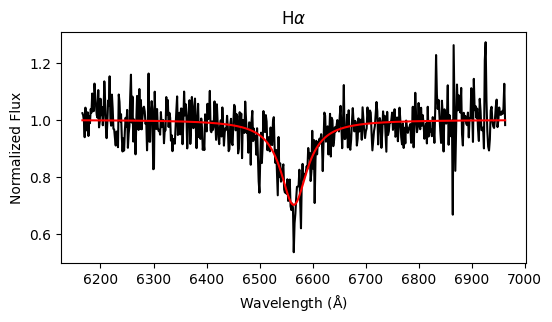

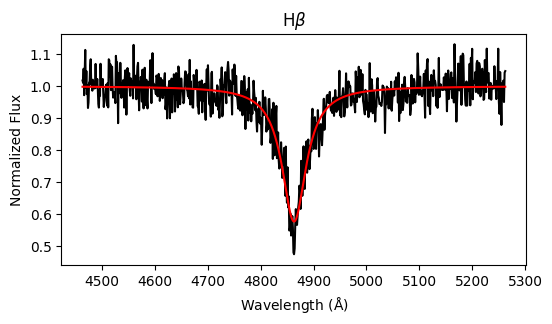

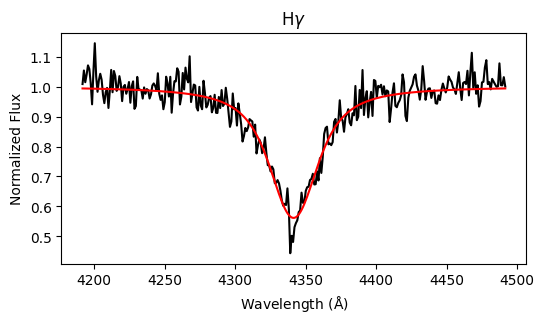

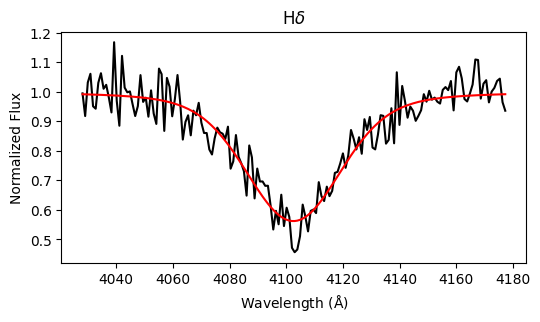

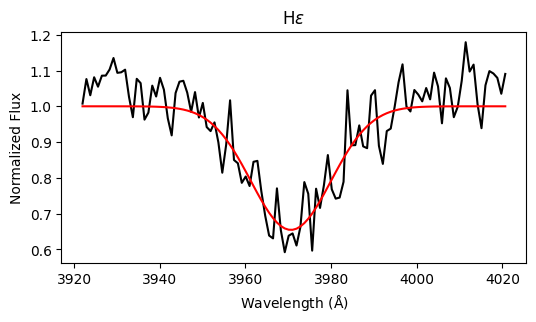

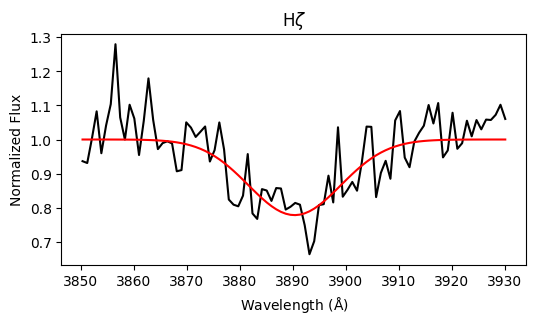

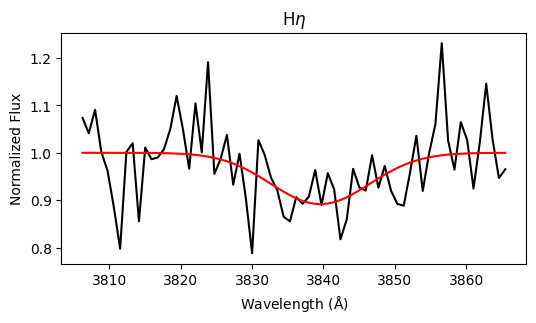

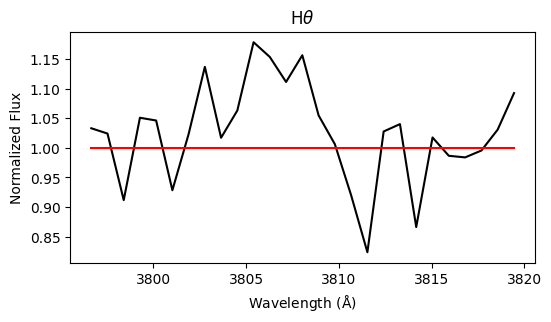

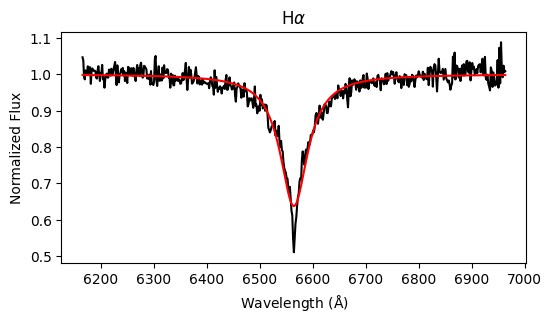

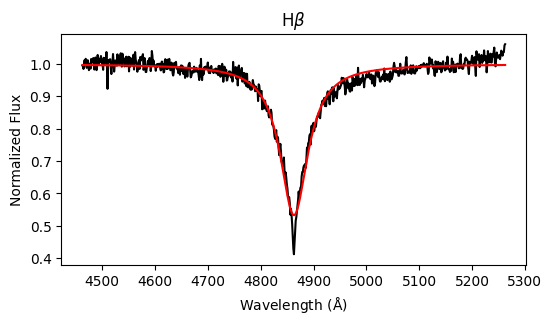

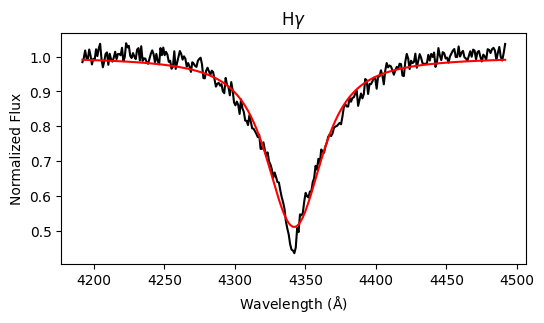

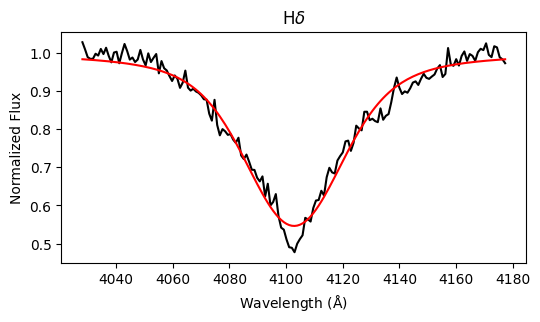

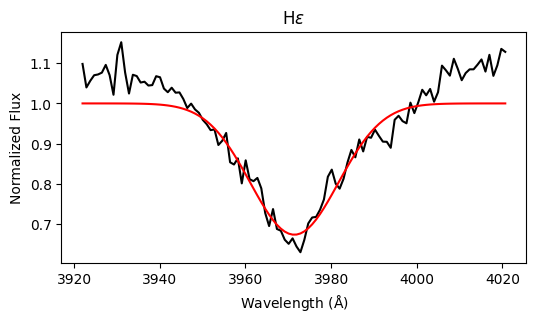

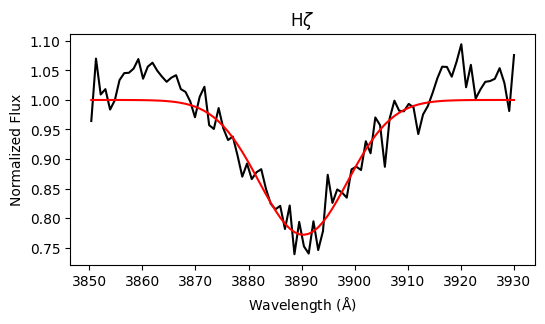

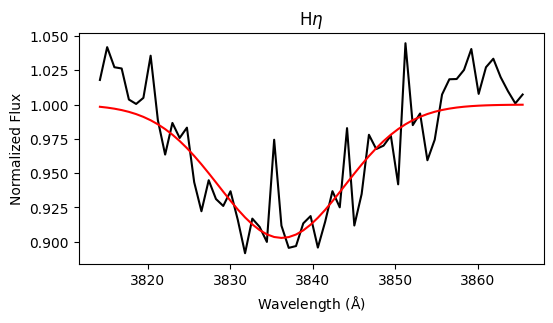

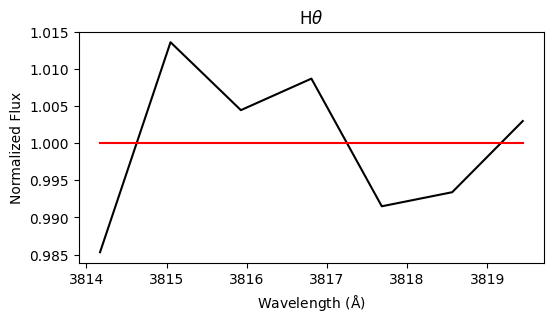

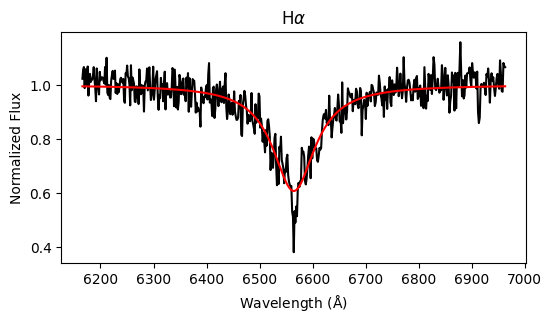

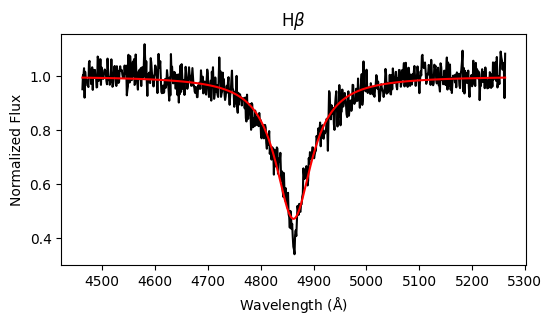

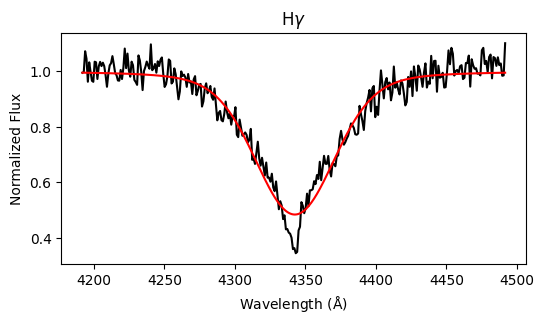

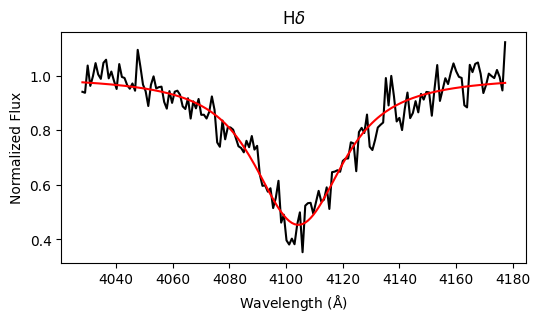

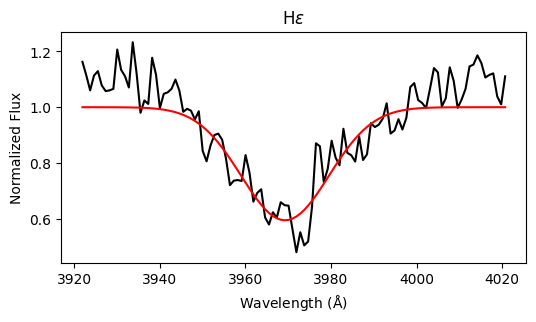

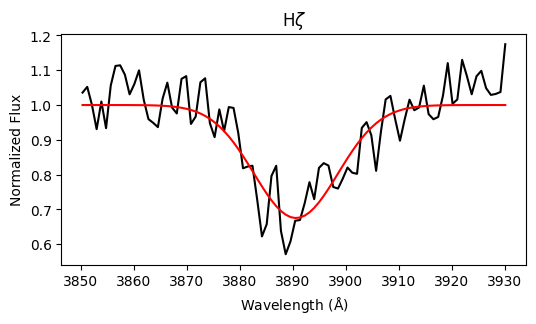

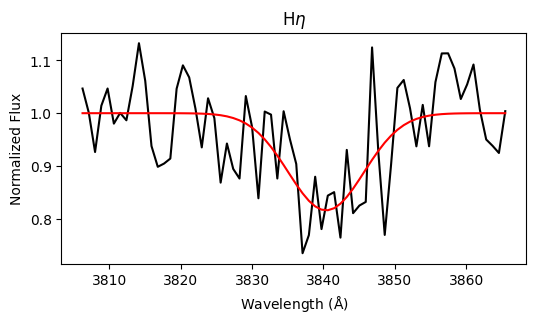

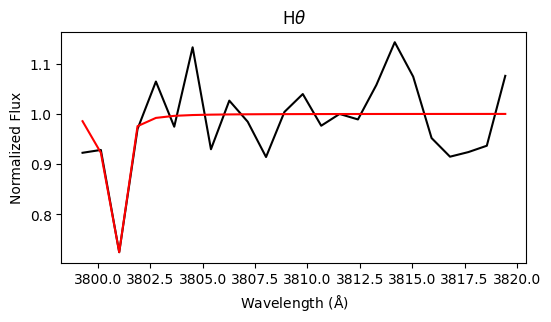

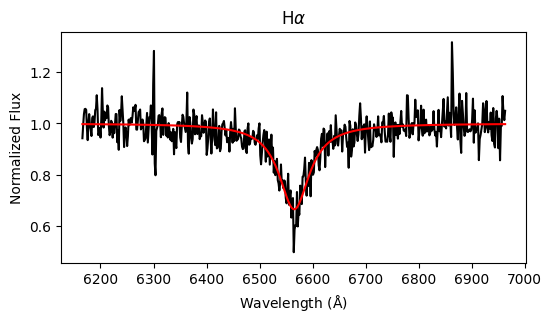

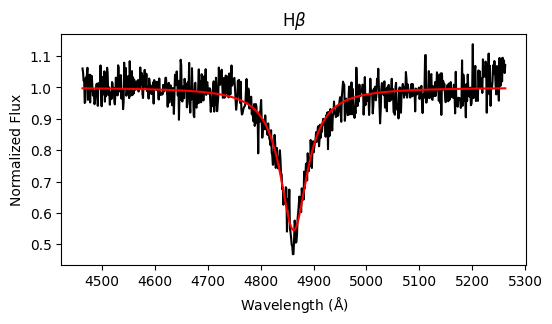

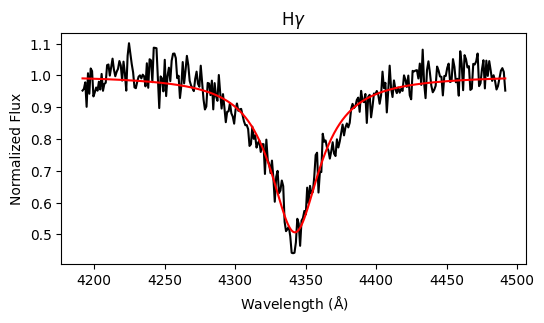

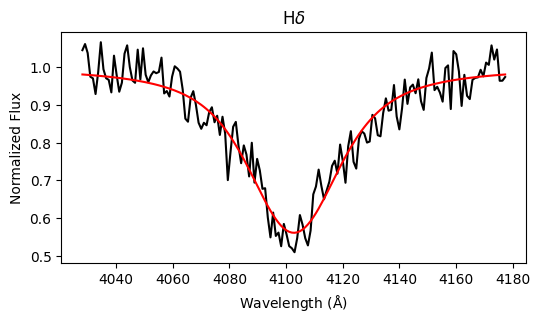

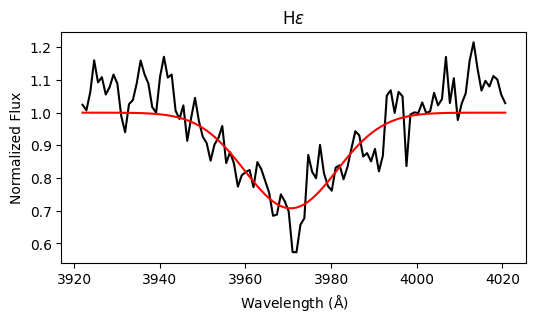

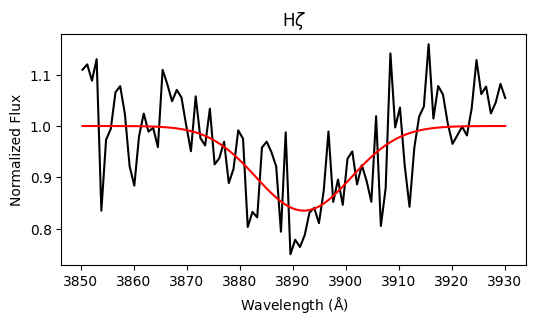

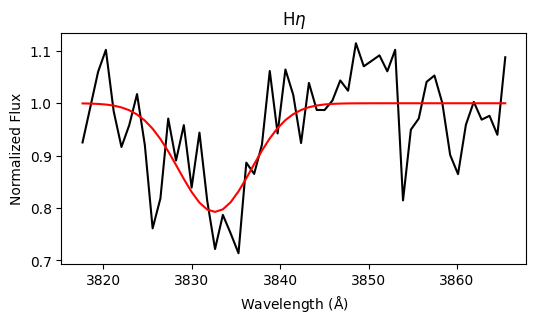

line profile fit failed! make sure the selected line is present on the provided spectrum
profile fit failed! returning NaN...


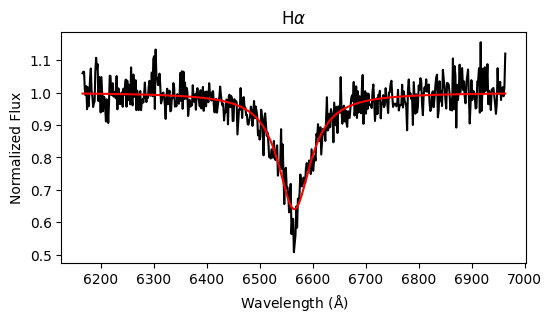

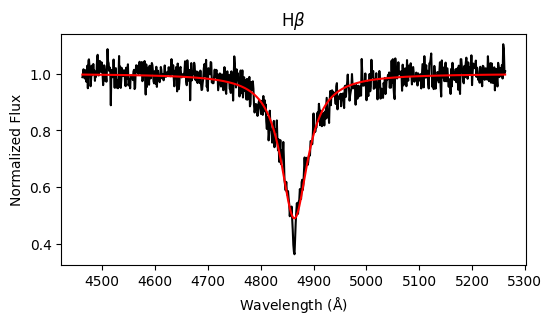

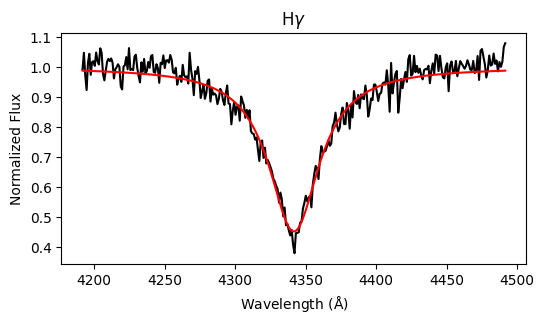

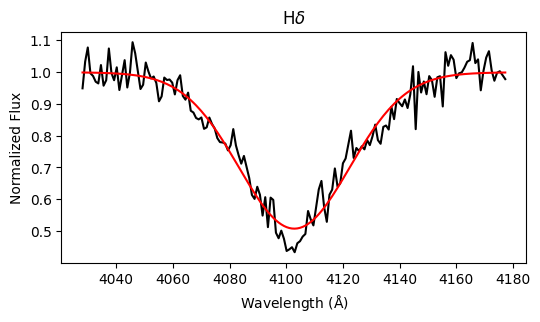

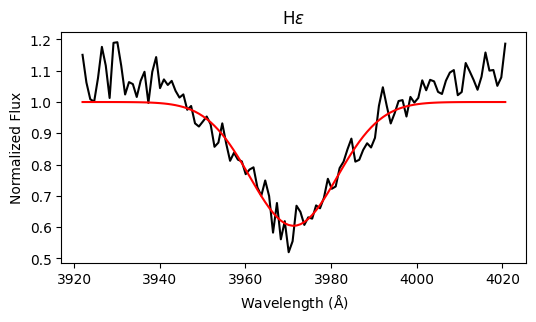

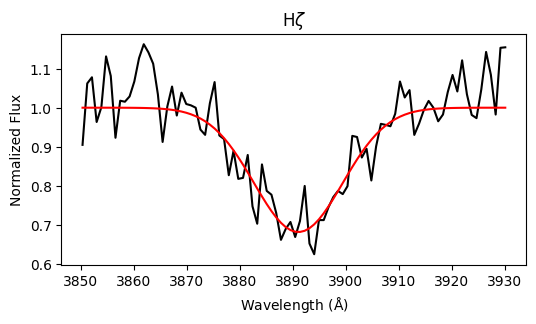

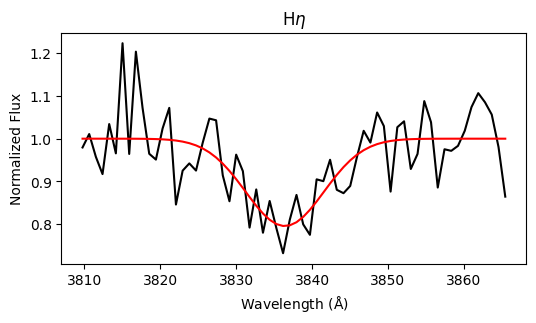

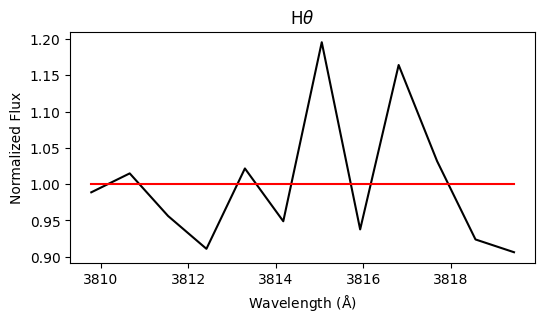

,Name,MPF,plx,e_plx,teff,e_teff,logg,e_logg,plxsp,e_plxsp,Comment,plate,mjd,fiber,pmf,snr,spec_avail,a_amp,a_center,a_sigma,a_gamma,a_fwhm,a_height,b_amp,b_center,b_sigma,b_gamma,b_fwhm,b_height,g_amp,g_center,g_sigma,g_gamma,g_fwhm,g_height,d_amp,d_center,d_sigma,d_gamma,d_fwhm,d_height,e_amp,e_center,e_sigma,e_gamma,e_fwhm,e_height,z_amp,z_center,z_sigma,z_gamma,z_fwhm,z_height,n_amp,n_center,n_sigma,n_gamma,n_fwhm,n_height,t_amp,t_center,t_sigma,t_gamma,t_fwhm,t_height
0,SDSS J000022.88-000635.7,51791-0387-166,2.41460,0.28810,23013,473,7.443,0.064,1.84623,0.12224,NaN,387,51791,166,38751791166,15.785736,0,28.496596,6564.462365,1.181225e-03,30.316875,60.633934,0.299198,36.701917,4862.943285,0.000939,27.593076,55.186319,0.423388,26.452560,4341.444413,7.631304,16.496071,41.274286,0.438343,21.332424,4102.544845,13.954124,6.400770,40.238635,0.437997,8.075324,3970.609669,9.324799,8.685830e-10,21.958037,0.345486,4.832580,3890.348476,8.682652,3.001839e-08,20.445909,0.222043,1.870683,3839.557659,6.891727,1.945673e-08,16.228638,0.108288,6.048440e-10,3789.374704,134.764834,86.927718,420.440060,1.143967e-12
1,SDSS J000034.06-052922.4,54380-2624-261,5.12254,0.17227,20299,148,7.799,0.022,5.23086,0.10821,NaN,2624,54380,261,262454380261,43.822166,0,36.254906,6564.465440,8.606356e-07,31.824474,63.649142,0.362623,47.126504,4862.981329,0.000007,32.106722,64.213638,0.467218,33.545616,4341.961325,8.262426,18.996463,46.601776,0.489402,25.220847,4102.843317,12.353261,10.912607,42.479638,0.453648,8.418953,3971.414838,10.253536,1.545728e-08,24.145027,0.327563,4.769225,3890.326323,8.329199,1.237843e-09,19.613598,0.228431,1.871047,3836.213844,7.675767,2.476241e-10,18.074896,0.097246,1.657939e-03,3824.398189,199.888866,199.619883,719.478317,1.732322e-06
2,SDSS J000034.07-010820.0,52203-0685-187,5.68123,0.23765,13006,222,8.025,0.054,5.59269,0.25335,NaN,685,52203,187,68552203187,18.881496,0,59.735099,6564.504098,4.328951e-04,48.323021,96.646335,0.393483,69.296665,4862.141475,0.000019,41.764896,83.530046,0.528142,41.203602,4342.430536,24.388746,8.781938,67.399087,0.516905,29.793471,4104.322905,6.399522,15.221949,36.959704,0.546333,10.415852,3969.263752,10.248120,1.027245e-09,24.132272,0.405472,6.444218,3890.599643,7.917735,2.839784e-08,18.644682,0.324698,2.450393,3840.373180,5.308609,6.065663e-07,12.500714,0.184147,4.617575e-01,3800.755062,0.000020,0.223760,0.447521,6.568732e-01
3,SDSS J000051.85+272405.3,54452-2824-272,2.17536,0.38865,21961,371,7.946,0.051,2.25211,0.10966,NaN,2824,54452,272,282454452272,19.776146,0,36.517659,6565.287572,1.659045e-04,34.724233,69.448677,0.334750,45.014685,4862.203073,0.000619,31.493427,62.987045,0.454972,32.925825,4342.404030,0.000021,21.228316,42.456762,0.493709,24.469784,4102.769866,8.334584,14.354570,39.090604,0.438816,7.871952,3970.563557,10.737579,5.395684e-12,25.284852,0.292473,3.708661,3892.068773,8.967306,1.185118e-07,21.116213,0.164993,2.145638,3832.635892,4.127852,1.747707e-07,9.720266,0.207368,NaN,NaN,NaN,NaN,NaN,NaN
4,SDSS J000100.42-042742.9,54327-2630-359,2.41227,0.32521,17138,225,7.604,0.041,2.50832,0.09545,NaN,2630,54327,359,263054327359,24.220581,0,42.525899,6565.322249,1.426203e-04,37.673203,75.346636,0.359311,49.756820,4863.697491,0.000099,31.084344,62.168876,0.509520,37.557657,4341.698519,0.000214,21.788907,43.577946,0.548672,24.597135,4102.866712,19.288556,0.805040,46.287622,0.492231,10.094919,3971.229989,10.177488,9.314771e-10,23.965947,0.395706,6.650201,3891.049150,8.357056,1.237168e-08,19.679194,0.317462,2.642160,3836.413833,5.160800,6.476375e-10,12.152651,0.204245,2.370762e-02,3775.210626,192.672225,199.999994,704.251877,2.517670e-05


In [15]:
#show some fits
output=fit_voigt(tab_dict['set_'+str(0)][:5],plot=True)
display(output)

In [16]:
def parallelprocess_fit_voigt(i):
    tab_dict['set_'+str(i)]=fit_voigt(tab_dict['set_'+str(i)],plot=False)

    #save as a .csv
    tab_dict['set_'+str(i)].to_csv('data/wdtools_training/short_sets/'+str(i)+'.csv',
                                   index=False)
    

In [ ]:
#run for each set
print(num_tables)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_fit_voigt)(i) for i in range(num_tables))


In [18]:
#read back in data
tab_dict={}
for i in tqdm(range(num_tables)):
    tab_dict['set_'+str(i)]=pd.read_csv('data/wdtools_training/short_sets/'+str(i)+'.csv')

#combine all of the dfs into one df
tremblay_training=pd.concat([tab_dict['set_0'], tab_dict['set_1']], ignore_index=True)
for i in range(num_tables-2):
    tremblay_training=pd.concat([tremblay_training, tab_dict['set_'+str(i+2)]], ignore_index=True)
#save the results of fitting the line profiles
tremblay_training.to_csv('data/wdtools_training/tremblay_training_set.csv',index=False)
display(tremblay_training)

100%|██████████████████████████████████████████| 12/12 [00:00<00:00, 237.09it/s]


,Name,MPF,plx,e_plx,teff,e_teff,logg,e_logg,plxsp,e_plxsp,Comment,plate,mjd,fiber,pmf,snr,spec_avail,a_amp,a_center,a_sigma,a_gamma,a_fwhm,a_height,b_amp,b_center,b_sigma,b_gamma,b_fwhm,b_height,g_amp,g_center,g_sigma,g_gamma,g_fwhm,g_height,d_amp,d_center,d_sigma,d_gamma,d_fwhm,d_height,e_amp,e_center,e_sigma,e_gamma,e_fwhm,e_height,z_amp,z_center,z_sigma,z_gamma,z_fwhm,z_height,n_amp,n_center,n_sigma,n_gamma,n_fwhm,n_height,t_amp,t_center,t_sigma,t_gamma,t_fwhm,t_height
0,SDSS J000022.88-000635.7,51791-0387-166,2.41460,0.28810,23013,473,7.443,0.064,1.84623,0.12224,NaN,387,51791,166,38751791166,15.785736,0,28.496596,6564.462365,1.181225e-03,30.316875,60.633934,0.299198,36.701917,4862.943285,0.000939,27.593076,55.186319,0.423388,26.452560,4341.444413,7.631304,16.496071,41.274286,0.438343,21.332424,4102.544845,13.954124,6.400770,40.238635,0.437997,8.075324,3970.609669,9.324799,8.685830e-10,21.958037,0.345486,4.832580,3890.348476,8.682652,3.001839e-08,20.445909,0.222043,1.870683,3839.557659,6.891727,1.945673e-08,16.228638,0.108288,6.048440e-10,3789.374704,134.764834,8.692772e+01,420.440060,1.143967e-12
1,SDSS J000034.06-052922.4,54380-2624-261,5.12254,0.17227,20299,148,7.799,0.022,5.23086,0.10821,NaN,2624,54380,261,262454380261,43.822166,0,36.254906,6564.465440,8.606356e-07,31.824474,63.649142,0.362623,47.126504,4862.981329,0.000007,32.106722,64.213638,0.467218,33.545616,4341.961325,8.262426,18.996463,46.601776,0.489402,25.220847,4102.843317,12.353261,10.912607,42.479638,0.453648,8.418953,3971.414838,10.253536,1.545728e-08,24.145027,0.327563,4.769225,3890.326323,8.329199,1.237843e-09,19.613598,0.228431,1.871047,3836.213844,7.675767,2.476241e-10,18.074896,0.097246,1.657939e-03,3824.398189,199.888866,1.996199e+02,719.478317,1.732322e-06
2,SDSS J000034.07-010820.0,52203-0685-187,5.68123,0.23765,13006,222,8.025,0.054,5.59269,0.25335,NaN,685,52203,187,68552203187,18.881496,0,59.735099,6564.504098,4.328951e-04,48.323021,96.646335,0.393483,69.296665,4862.141475,0.000019,41.764896,83.530046,0.528142,41.203602,4342.430536,24.388746,8.781938,67.399087,0.516905,29.793471,4104.322905,6.399522,15.221949,36.959704,0.546333,10.415852,3969.263752,10.248120,1.027245e-09,24.132272,0.405472,6.444218,3890.599643,7.917735,2.839784e-08,18.644682,0.324698,2.450393,3840.373180,5.308609,6.065663e-07,12.500714,0.184147,4.617575e-01,3800.755062,0.000020,2.237601e-01,0.447521,6.568732e-01
3,SDSS J000051.85+272405.3,54452-2824-272,2.17536,0.38865,21961,371,7.946,0.051,2.25211,0.10966,NaN,2824,54452,272,282454452272,19.776146,0,36.517659,6565.287572,1.659045e-04,34.724233,69.448677,0.334750,45.014685,4862.203073,0.000619,31.493427,62.987045,0.454972,32.925825,4342.404030,0.000021,21.228316,42.456762,0.493709,24.469784,4102.769866,8.334584,14.354570,39.090604,0.438816,7.871952,3970.563557,10.737579,5.395684e-12,25.284852,0.292473,3.708661,3892.068773,8.967306,1.185118e-07,21.116213,0.164993,2.145638,3832.635892,4.127852,1.747707e-07,9.720266,0.207368,NaN,NaN,NaN,NaN,NaN,NaN
4,SDSS J000100.42-042742.9,54327-2630-359,2.41227,0.32521,17138,225,7.604,0.041,2.50832,0.09545,NaN,2630,54327,359,263054327359,24.220581,0,42.525899,6565.322249,1.426203e-04,37.673203,75.346636,0.359311,49.756820,4863.697491,0.000099,31.084344,62.168876,0.509520,37.557657,4341.698519,0.000214,21.788907,43.577946,0.548672,24.597135,4102.866712,19.288556,0.805040,46.287622,0.492231,10.094919,3971.229989,10.177488,9.314771e-10,23.965947,0.395706,6.650201,3891.049150,8.357056,1.237168e-08,19.679194,0.317462,2.642160,3836.413833,5.160800,6.476375e-10,12.152651,0.204245,2.370762e-02,3775.210626,192.672225,2.000000e+02,704.251877,2.517670e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5889,SDSS J235751.84+083156.7,55860-4535-0545,2.67411,0.29789,18616,338,7.935,0.058,2.54095,0.1

### Train the PRF routine
- Use the first 6 lines
    - Higher order lines are noisy and result in more failed fits/lower accuracy
    - 6 lines is best balance of fitting as many as possible without noise disrupting the fit

In [19]:
lp = LineProfiles(training_set='Nicole',lines = ['alpha','beta','gamma','delta','epsilon','zeta'])


# Import the datasets

In [20]:
# read in the short tables, either from the backup file or from the latest version of the table
backup=False

if backup==True:
    #read in all object id lists
    SDSSV_num_id_sets=np.genfromtxt('csv/SDSSV_num_id_sets.txt',dtype=int)
    id_SDSSV_dict={}
    for i in tqdm(range(SDSSV_num_id_sets)):
        id_SDSSV_dict['set_'+str(i)]=np.genfromtxt('csv/SDSSV_short_sets/SDSSV_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    SDSSV_dict={}
    size=0
    for i in tqdm(range(SDSSV_num_id_sets)):
        SDSSV_dict['set_'+str(i)]=pd.read_csv('csv/SDSSV_short_sets/set_'+str(i)+'_nb03.csv')
        size=size+len(SDSSV_dict['set_'+str(i)])
        
    #read in all object id lists
    eSDSS_num_id_sets=np.genfromtxt('csv/eSDSS_num_id_sets.txt',dtype=int)
    id_eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        id_eSDSS_dict['set_'+str(i)]=np.genfromtxt('csv/eSDSS_short_sets/eSDSS_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        eSDSS_dict['set_'+str(i)]=pd.read_csv('csv/eSDSS_short_sets/set_'+str(i)+'_nb03.csv')
        
else:
    #read in all object id lists
    SDSSV_num_id_sets=np.genfromtxt('csv/SDSSV_num_id_sets.txt',dtype=int)
    id_SDSSV_dict={}
    for i in tqdm(range(SDSSV_num_id_sets)):
        id_SDSSV_dict['set_'+str(i)]=np.genfromtxt('csv/SDSSV_short_sets/SDSSV_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    SDSSV_dict={}
    size=0
    for i in tqdm(range(SDSSV_num_id_sets)):
        SDSSV_dict['set_'+str(i)]=pd.read_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv')
        size=size+len(SDSSV_dict['set_'+str(i)])
        
     #read in all object id lists
    eSDSS_num_id_sets=np.genfromtxt('csv/eSDSS_num_id_sets.txt',dtype=int)
    id_eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        id_eSDSS_dict['set_'+str(i)]=np.genfromtxt('csv/eSDSS_short_sets/eSDSS_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        eSDSS_dict['set_'+str(i)]=pd.read_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv')


100%|██████████████████████████████████████████| 49/49 [00:00<00:00, 185.25it/s]


In [21]:
#read in the full tables, either from the backup file or from the latest version of the table
backup=False
if backup==True:
    SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df_nb03.csv')
    eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df_nb03.csv')
else:
    SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df.csv')
    eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df.csv')

# Define functions to fit the WD Teffs/Loggs using WDtools with PRF fits
From the WDtools validation, fitting with the PRF routine outperforms fitting with the GFP routine because the continuum normalization for the GFP routine sometimes fails.

For each SDSSV or eSDSS WD (keep the two sets separate):
- fit the logg/teff for each individual spectrum
- fit the logg/teff for the coadded spectrum
- take the weighted average logg/teff for each object but only for spectra passing the SNR cut (SNR>10)



In [22]:
def plot_spectrum(spec, SDSSType, ylim='default'):
    if SDSSType=='SDSSV':
        #spec is a fits file containing the SDSS spectra for the object in spec data model format
        #the coadded spectrum data is HDU1
        #spec = SDSS.get_spectra_async(plate, fiberID, mjd)[0].get_fits()
        
        wl = 10**spec[1].data['loglam'] #wavelength in angstroms
        fl = spec[1].data['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        ivar = spec[1].data['ivar'] #inverse variance of the flux, the error on the flux is ivar^-0.5
        
    if SDSSType=='eSDSS':
        #spec is early SDSS data filename
        npzfile = np.load('csv/eSDSS_spectra/'+spec+'.npz')
        wl = npzfile['wavl'] #wavelength in angstroms
        fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        ivar = npzfile['ivar'] #inverse variance of the flux, the error on the flux is ivar^-0.5
        
    if SDSSType=='coadd':
        #spec is array of wl,fl,ivar
        wl=spec[0]
        fl=spec[1]
        ivar=spec[2]
    
    balmer_lines=[6564.61, 4862.68, 4341.68, 4102.89, 3971.20, 3890.12, 3835.5, 3799.5]
    #hydrogen emission lines in angstroms for vacuum
    
    fig, ax=plt.subplots(1,1,figsize=(12,6))
    plt.style.use('stefan.mplstyle')
    ax.plot(wl, fl)
    
    if ylim=='default':
        min_, max_ = plt.ylim()
    else:
        min_=ylim[0]
        max_=ylim[1]
    ax.set_ylim((min_,max_))
    ax.vlines(balmer_lines, min_, max_, colors = 'black', linestyle = 'dashed', alpha = 0.5)
    ax.set_ylabel(r'Flux [$10^{-17} \mathrm{ergs/s/cm^2/\AA}$]')
    ax.set_xlabel(r'Wavelength [$\mathrm{\AA}$]')
    plt.title('WD Spectrum')
    
    return(wl,fl,ivar,fig)

In [23]:
def fit_PRF_SDSSV(obj_id,table,plot=False):
    #this function fits the spectrum TEFF and LOGG using WDtools Parametric Random Forest Method
    #for each WD coadd and all individual spectra
    
    obj_id_int=int(obj_id)
    wd_table=table.query('gaia_dr3_source_id==@obj_id_int')
    #reset the indices
    indices=np.arange(0,len(wd_table))
    wd_table.set_index(indices,inplace=True)
    
    #get the data for the spectra
    ind_teff_prfs=[]
    e_ind_teff_prfs=[]
    ind_logg_prfs=[]
    e_ind_logg_prfs=[]
    
    for ind in range(len(wd_table)):
        # Open the SDSS-V fits file
        fieldid=str(wd_table['fieldid'][ind])
        if len(fieldid)<6:
            fieldid='0'+fieldid
        mjd=str(wd_table['mjd'][ind])
        catalogid=str(wd_table['catalogid'][ind])
        fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
        url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
       
        with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
            # Get pertinent spectrum data    
            wl = np.array(10**spec[1].data['loglam'])
            fl = np.array(spec[1].data['flux'])
            ivar = np.array(spec[1].data['ivar'])
            if plot==True:
                print('Individual Spectrum')
                #plot the spectrum
                ymin=-10
                ymax=max(fl[500:])
                output=plot_spectrum(spec,SDSSType='SDSSV',ylim=(ymin,ymax))
                plt.show()
            try:
                #fit the model using wdtools
                results = lp.labels_from_spectrum(wl, fl, make_plot = plot)
                #print('Teff = %i ± %i Kelvin' % (results[0], results[1]))
                #print('logg = %.2f ± %.2f log[cm/s^2]' % (results[2], results[3]))
            except:
                print('FIT FAILED')
                display(wd_table.loc[ind:ind])
                results=(np.nan,np.nan,np.nan,np.nan)
            ind_teff_prfs.append(results[0])
            e_ind_teff_prfs.append(results[1])
            ind_logg_prfs.append(results[2])
            e_ind_logg_prfs.append(results[3])
                
                
    #if there is more than 1 spectrum associated with the object, load the coadd data and fit that too
    nexp=len(wd_table)
    if nexp>1:
        #import data
        npzfile = np.load('csv/SDSSV_coadds/'+str(obj_id)+'.npz')
        coadd_wl = npzfile['wavl'] #wavelength in angstroms
        coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
        coadd_snr = npzfile['snr']
        if plot==True:
            print('Coadded Spectrum, SNR='+str(coadd_snr))
            #plot the spectrum
            ymin=-10
            ymax=max(fl[500:])
            spec=[coadd_wl,coadd_fl,coadd_ivar]
            output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
            plt.show()
            
        try:
            #fit the model using wdtools
            results = lp.labels_from_spectrum(coadd_wl, coadd_fl, make_plot = plot)
            #print('Teff = %i ± %i Kelvin' % (results[0], results[1]))
            #print('logg = %.2f ± %.2f log[cm/s^2]' % (results[2], results[3]))
        except:
            print('COADD FIT FAILED')
            display(wd_table.loc[ind:ind])
            results=(np.nan,np.nan,np.nan,np.nan)
        coadd_teff_prf=results[0]
        e_coadd_teff_prf=results[1]
        coadd_logg_prf=results[2]
        e_coadd_logg_prf=results[3]
    #if there aren't multiple spectra to coadd, save the individual spectrum params
    else:
        coadd_teff_prf=ind_teff_prfs[0]
        e_coadd_teff_prf=e_ind_teff_prfs[0]
        coadd_logg_prf=ind_logg_prfs[0]
        e_coadd_logg_prf=e_ind_logg_prfs[0]

    return(ind_teff_prfs,e_ind_teff_prfs,ind_logg_prfs,e_ind_logg_prfs,coadd_teff_prf,e_coadd_teff_prf,
           coadd_logg_prf,e_coadd_logg_prf)


In [24]:
def fit_PRF_eSDSS(obj_id,table,plot=False):
    #this function fits the spectrum TEFF and LOGG using WDtools Parametric Random Forest Method
    #for each WD coadd and all individual spectra
    
    obj_id_int=int(obj_id)
    wd_table=table.query('gaia_dr3_source_id==@obj_id_int')
    #reset the indices
    indices=np.arange(0,len(wd_table))
    wd_table.set_index(indices,inplace=True)
    
    #get the data for the spectra
    ind_teff_prfs=[]
    e_ind_teff_prfs=[]
    ind_logg_prfs=[]
    e_ind_logg_prfs=[]
    
    for ind in range(len(wd_table)):
        plate=wd_table['plate'].loc[ind]
        mjd=wd_table['mjd'].loc[ind]
        fiber=wd_table['fiber'].loc[ind]   
        filename=str(wd_table['pmf'].loc[ind])
        #Get pertinent spectrum data 
        npzfile = np.load('csv/eSDSS_spectra/'+filename+'.npz')
        wl = npzfile['wavl'] #wavelength in angstroms
        fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
        if plot==True:
            print('Individual Spectrum')
            #plot the spectrum
            ymin=-10
            ymax=max(fl[500:])
            output=plot_spectrum(filename,SDSSType='eSDSS',ylim=(ymin,ymax))
            plt.show()
        try:
            #fit the model using wdtools
            results = lp.labels_from_spectrum(wl, fl, make_plot = plot)
            #print('Teff = %i ± %i Kelvin' % (results[0], results[1]))
            #print('logg = %.2f ± %.2f log[cm/s^2]' % (results[2], results[3]))
        except:
            print('FIT FAILED')
            display(wd_table.loc[ind:ind])
            results=(np.nan,np.nan,np.nan,np.nan)
        ind_teff_prfs.append(results[0])
        e_ind_teff_prfs.append(results[1])
        ind_logg_prfs.append(results[2])
        e_ind_logg_prfs.append(results[3])
                
                
    #if there is more than 1 spectrum associated with the object, load the coadd data and fit that too
    nexp=len(wd_table)
    if nexp>1:
        #import data
        npzfile = np.load('csv/eSDSS_coadds/'+str(obj_id)+'.npz')
        coadd_wl = npzfile['wavl'] #wavelength in angstroms
        coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
        coadd_snr = npzfile['snr']
        if plot==True:
            print('Coadded Spectrum, SNR='+str(coadd_snr))
            #plot the spectrum
            ymin=-10
            ymax=max(fl[500:])
            spec=[coadd_wl,coadd_fl,coadd_ivar]
            output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
            plt.show()
            
        try:
            #fit the model using wdtools
            results = lp.labels_from_spectrum(coadd_wl, coadd_fl, make_plot = plot)
            #print('Teff = %i ± %i Kelvin' % (results[0], results[1]))
            #print('logg = %.2f ± %.2f log[cm/s^2]' % (results[2], results[3]))
        except:
            print('COADD FIT FAILED')
            display(wd_table.loc[ind:ind])
            results=(np.nan,np.nan,np.nan,np.nan)
        coadd_teff_prf=results[0]
        e_coadd_teff_prf=results[1]
        coadd_logg_prf=results[2]
        e_coadd_logg_prf=results[3]
    #if there aren't multiple spectra to coadd, save the individual spectrum params
    else:
        coadd_teff_prf=ind_teff_prfs[0]
        e_coadd_teff_prf=e_ind_teff_prfs[0]
        coadd_logg_prf=ind_logg_prfs[0]
        e_coadd_logg_prf=e_ind_logg_prfs[0]

    return(ind_teff_prfs,e_ind_teff_prfs,ind_logg_prfs,e_ind_logg_prfs,coadd_teff_prf,e_coadd_teff_prf,
           coadd_logg_prf,e_coadd_logg_prf)



# Fit the Loggs and Teffs and save the results

### Show some fits

In [ ]:
i=0
obj_ids=id_SDSSV_dict['set_'+str(i)][3:4].astype(int)
table=SDSSV_dict['set_'+str(i)][SDSSV_dict['set_'+str(i)]['gaia_dr3_source_id'].isin(obj_ids)]
#reset the indices
indices=np.arange(0,len(table))
table.set_index(indices,inplace=True)

teff_prf_ind=np.array([])
e_teff_prf_ind=np.array([])
logg_prf_ind=np.array([])
e_logg_prf_ind=np.array([])
teff_prf_coadd=np.array([])
e_teff_prf_coadd=np.array([])
logg_prf_coadd=np.array([])
e_logg_prf_coadd=np.array([])

for obj_id in tqdm(obj_ids):
    print(obj_id)
    ind_teff_prfs,e_ind_teff_prfs,ind_logg_prfs,e_ind_logg_prfs,coadd_teff_prf,e_coadd_teff_prf,coadd_logg_prf,e_coadd_logg_prf=fit_PRF_SDSSV(obj_id,table,plot=True)
    teff_prf_ind=np.append(teff_prf_ind,ind_teff_prfs)
    e_teff_prf_ind=np.append(e_teff_prf_ind,e_ind_teff_prfs)
    logg_prf_ind=np.append(logg_prf_ind,ind_logg_prfs)
    e_logg_prf_ind=np.append(e_logg_prf_ind,e_ind_logg_prfs)
    teff_prf_coadd=np.append(teff_prf_coadd,np.full(len(ind_teff_prfs),coadd_teff_prf))
    e_teff_prf_coadd=np.append(e_teff_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_teff_prf))
    logg_prf_coadd=np.append(logg_prf_coadd,np.full(len(ind_teff_prfs),coadd_logg_prf))
    e_logg_prf_coadd=np.append(e_logg_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_logg_prf))

table['teff_prf_ind']=teff_prf_ind.flatten()
table['e_teff_prf_ind']=e_teff_prf_ind.flatten()
table['logg_prf_ind']=logg_prf_ind.flatten()
table['e_logg_prf_ind']=e_logg_prf_ind.flatten()
table['teff_prf_coadd']=teff_prf_coadd.flatten()
table['e_teff_prf_coadd']=e_teff_prf_coadd.flatten()
table['logg_prf_coadd']=logg_prf_coadd.flatten()
table['e_logg_prf_coadd']=e_logg_prf_coadd.flatten()

display(table)

In [ ]:
i=0
obj_ids=id_eSDSS_dict['set_'+str(i)][5:6].astype(int)
table=eSDSS_dict['set_'+str(i)][eSDSS_dict['set_'+str(i)]['gaia_dr3_source_id'].isin(obj_ids)]
#reset the indices
indices=np.arange(0,len(table))
table.set_index(indices,inplace=True)

teff_prf_ind=np.array([])
e_teff_prf_ind=np.array([])
logg_prf_ind=np.array([])
e_logg_prf_ind=np.array([])
teff_prf_coadd=np.array([])
e_teff_prf_coadd=np.array([])
logg_prf_coadd=np.array([])
e_logg_prf_coadd=np.array([])

for obj_id in tqdm(obj_ids):
    ind_teff_prfs,e_ind_teff_prfs,ind_logg_prfs,e_ind_logg_prfs,coadd_teff_prf,e_coadd_teff_prf,coadd_logg_prf,e_coadd_logg_prf=fit_PRF_eSDSS(obj_id,table,plot=True)
    teff_prf_ind=np.append(teff_prf_ind,ind_teff_prfs)
    e_teff_prf_ind=np.append(e_teff_prf_ind,e_ind_teff_prfs)
    logg_prf_ind=np.append(logg_prf_ind,ind_logg_prfs)
    e_logg_prf_ind=np.append(e_logg_prf_ind,e_ind_logg_prfs)
    teff_prf_coadd=np.append(teff_prf_coadd,np.full(len(ind_teff_prfs),coadd_teff_prf))
    e_teff_prf_coadd=np.append(e_teff_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_teff_prf))
    logg_prf_coadd=np.append(logg_prf_coadd,np.full(len(ind_teff_prfs),coadd_logg_prf))
    e_logg_prf_coadd=np.append(e_logg_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_logg_prf))

table['teff_prf_ind']=teff_prf_ind.flatten()
table['e_teff_prf_ind']=e_teff_prf_ind.flatten()
table['logg_prf_ind']=logg_prf_ind.flatten()
table['e_logg_prf_ind']=e_logg_prf_ind.flatten()
table['teff_prf_coadd']=teff_prf_coadd.flatten()
table['e_teff_prf_coadd']=e_teff_prf_coadd.flatten()
table['logg_prf_coadd']=logg_prf_coadd.flatten()
table['e_logg_prf_coadd']=e_logg_prf_coadd.flatten()

display(table)

### Show fits for SDSS spectra with SNR~5, 10, and 20

5.027812480926514


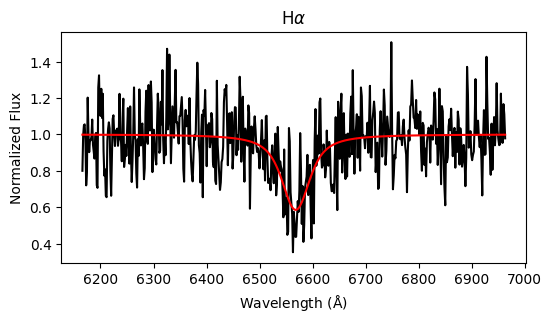

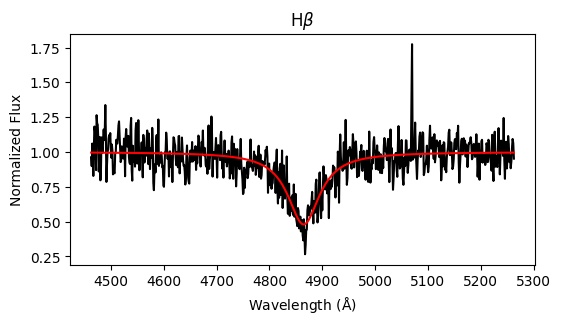

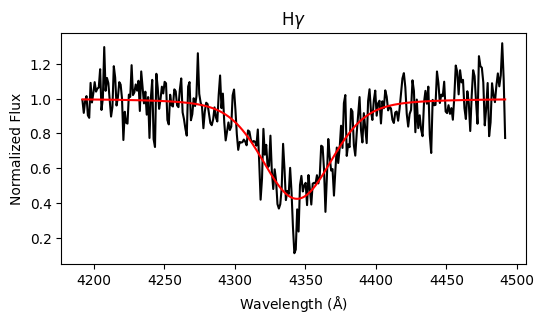

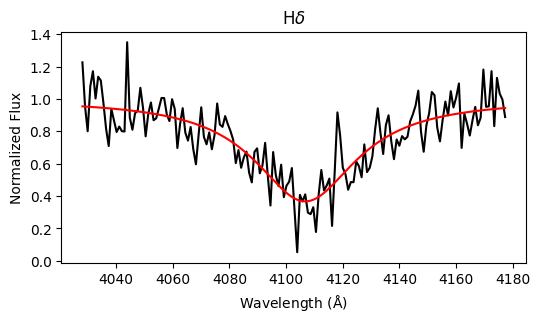

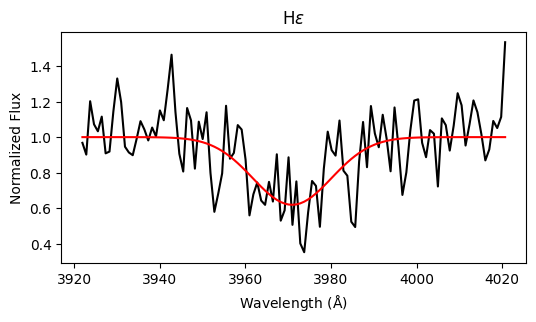

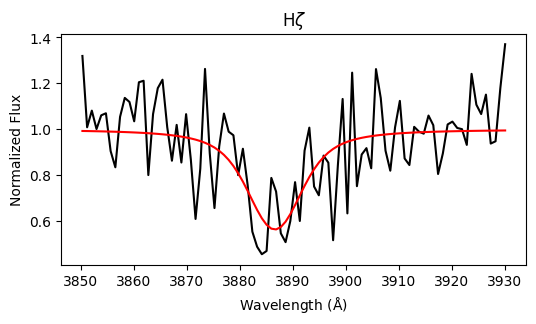

9.977349281311035


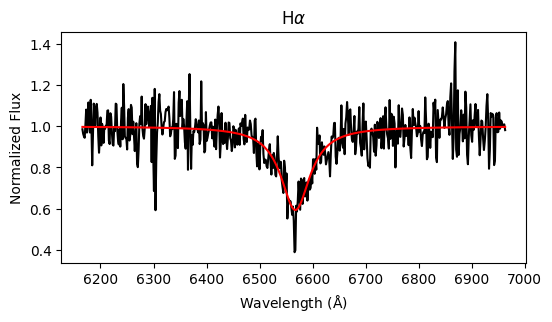

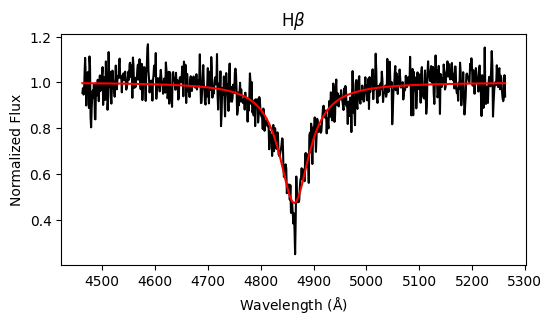

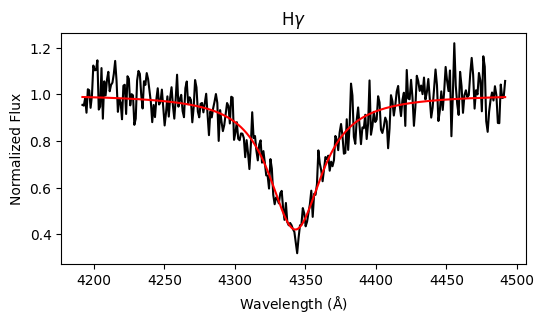

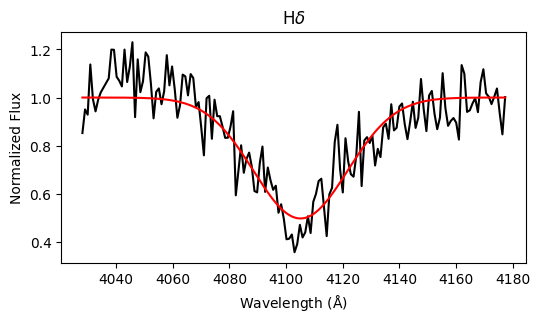

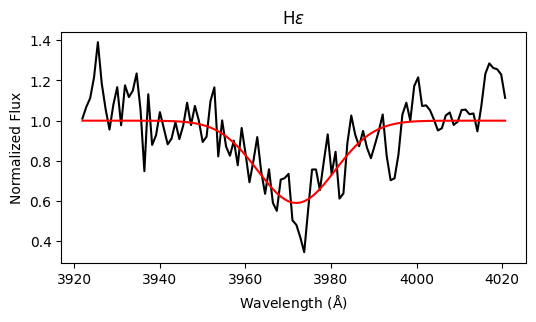

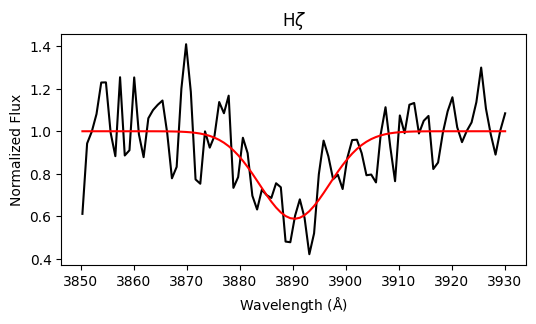

20.0249080657959


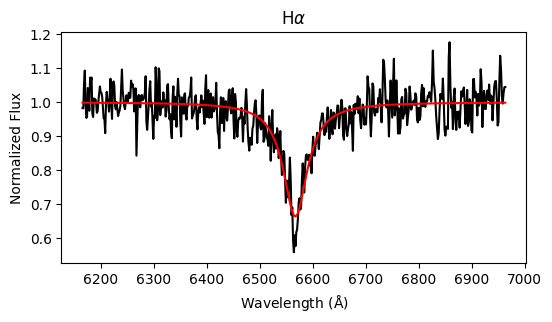

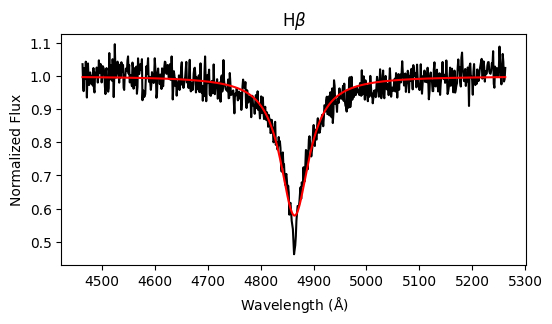

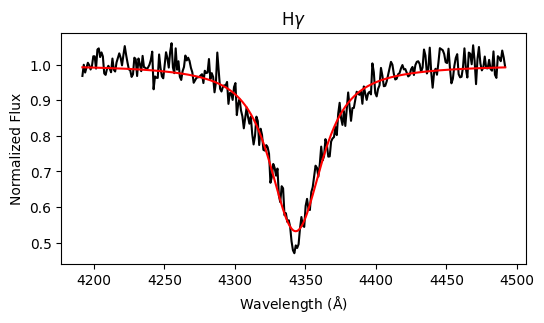

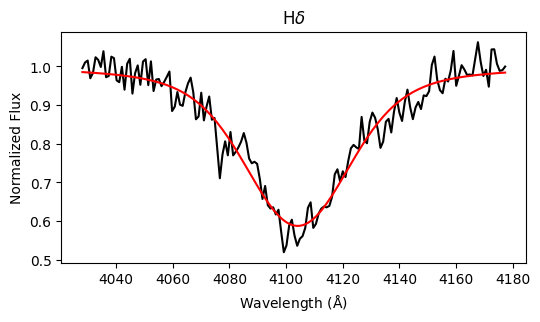

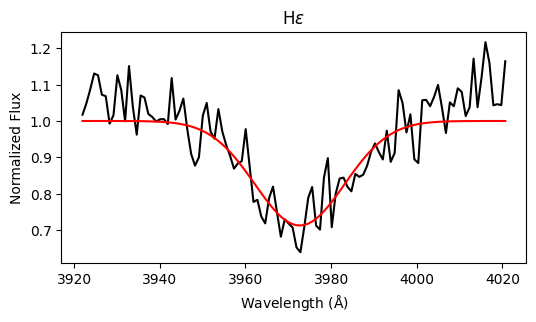

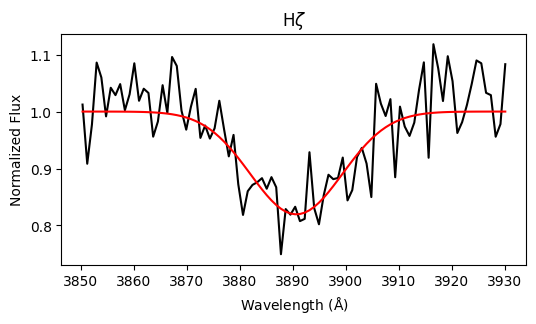

In [25]:
num_id5=1 #which table
obj_id5=671200102992315264 #which object
mjd5=59302 #which observation
wd_table5=SDSSV_dict['set_'+str(num_id5)].query('gaia_dr3_source_id==@obj_id5 and mjd==@mjd5')
#reset the indices
indices=np.arange(0,len(wd_table5))
wd_table5.set_index(indices,inplace=True)
snr5=wd_table5['snr'][0]

num_id10=1
obj_id10=683776390006118656
mjd10=59202
wd_table10=SDSSV_dict['set_'+str(num_id10)].query('gaia_dr3_source_id==@obj_id10 and mjd==@mjd10')
#reset the indices
indices=np.arange(0,len(wd_table10))
wd_table10.set_index(indices,inplace=True)
snr10=wd_table10['snr'][0]

num_id20=2
obj_id20=877876093938694912
mjd20=59167
wd_table20=SDSSV_dict['set_'+str(num_id20)].query('gaia_dr3_source_id==@obj_id20 and mjd==@mjd20')
#reset the indices
indices=np.arange(0,len(wd_table20))
wd_table20.set_index(indices,inplace=True)
snr20=wd_table20['snr'][0]

wd_tables=[wd_table5,wd_table10,wd_table20]
snrs=[snr5,snr10,snr20]

plotnum=1
for i in range(len(snrs)):
    wd_table=wd_tables[i]
    snr=snrs[i]
    # Open the SDSS-V fits file
    fieldid=str(wd_table['fieldid'][0])
    if len(fieldid)<6:
        fieldid='0'+fieldid
    mjd=str(wd_table['mjd'][0])
    catalogid=str(wd_table['catalogid'][0])
    fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
    url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
    
    with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
        # Get pertinent spectrum data    
        wl = np.array(10**spec[1].data['loglam'])
        fl = np.array(spec[1].data['flux'])
        ivar = np.array(spec[1].data['ivar'])
    print(snr)
    #fit the individual spectra and show the plots
    results = lp.labels_from_spectrum(wl, fl, make_plot = True)
    #SCREENSHOT AND SAVE PLOTS IF NEEDED
    

### Fit all Loggs/Teffs

In [26]:
def parallelprocess_fit_PRF_SDSSV(i):
    obj_ids=id_SDSSV_dict['set_'+str(i)].astype(int)

    teff_prf_ind=np.array([])
    e_teff_prf_ind=np.array([])
    logg_prf_ind=np.array([])
    e_logg_prf_ind=np.array([])
    teff_prf_coadd=np.array([])
    e_teff_prf_coadd=np.array([])
    logg_prf_coadd=np.array([])
    e_logg_prf_coadd=np.array([])
    for obj_id in obj_ids:
        ind_teff_prfs,e_ind_teff_prfs,ind_logg_prfs,e_ind_logg_prfs,coadd_teff_prf,e_coadd_teff_prf,coadd_logg_prf,e_coadd_logg_prf=fit_PRF_SDSSV(obj_id,SDSSV_dict['set_'+str(i)])
        teff_prf_ind=np.append(teff_prf_ind,ind_teff_prfs)
        e_teff_prf_ind=np.append(e_teff_prf_ind,e_ind_teff_prfs)
        logg_prf_ind=np.append(logg_prf_ind,ind_logg_prfs)
        e_logg_prf_ind=np.append(e_logg_prf_ind,e_ind_logg_prfs)
        teff_prf_coadd=np.append(teff_prf_coadd,np.full(len(ind_teff_prfs),coadd_teff_prf))
        e_teff_prf_coadd=np.append(e_teff_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_teff_prf))
        logg_prf_coadd=np.append(logg_prf_coadd,np.full(len(ind_teff_prfs),coadd_logg_prf))
        e_logg_prf_coadd=np.append(e_logg_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_logg_prf))
        
    SDSSV_dict['set_'+str(i)]['teff_prf_ind']=teff_prf_ind.flatten()
    SDSSV_dict['set_'+str(i)]['e_teff_prf_ind']=e_teff_prf_ind.flatten()
    SDSSV_dict['set_'+str(i)]['logg_prf_ind']=logg_prf_ind.flatten()
    SDSSV_dict['set_'+str(i)]['e_logg_prf_ind']=e_logg_prf_ind.flatten()
    SDSSV_dict['set_'+str(i)]['teff_prf_coadd']=teff_prf_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['e_teff_prf_coadd']=e_teff_prf_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['logg_prf_coadd']=logg_prf_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['e_logg_prf_coadd']=e_logg_prf_coadd.flatten()

    #save as a .csv
    SDSSV_dict['set_'+str(i)].to_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv',index=False)
    #save to back up
    SDSSV_dict['set_'+str(i)].to_csv('csv/SDSSV_short_sets/set_'+str(i)+'_nb04.csv',index=False)
    

In [27]:
def parallelprocess_fit_PRF_eSDSS(i):
    obj_ids=id_eSDSS_dict['set_'+str(i)].astype(int)

    teff_prf_ind=np.array([])
    e_teff_prf_ind=np.array([])
    logg_prf_ind=np.array([])
    e_logg_prf_ind=np.array([])
    teff_prf_coadd=np.array([])
    e_teff_prf_coadd=np.array([])
    logg_prf_coadd=np.array([])
    e_logg_prf_coadd=np.array([])
    for obj_id in obj_ids:
        ind_teff_prfs,e_ind_teff_prfs,ind_logg_prfs,e_ind_logg_prfs,coadd_teff_prf,e_coadd_teff_prf,coadd_logg_prf,e_coadd_logg_prf=fit_PRF_eSDSS(obj_id,eSDSS_dict['set_'+str(i)])
        teff_prf_ind=np.append(teff_prf_ind,ind_teff_prfs)
        e_teff_prf_ind=np.append(e_teff_prf_ind,e_ind_teff_prfs)
        logg_prf_ind=np.append(logg_prf_ind,ind_logg_prfs)
        e_logg_prf_ind=np.append(e_logg_prf_ind,e_ind_logg_prfs)
        teff_prf_coadd=np.append(teff_prf_coadd,np.full(len(ind_teff_prfs),coadd_teff_prf))
        e_teff_prf_coadd=np.append(e_teff_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_teff_prf))
        logg_prf_coadd=np.append(logg_prf_coadd,np.full(len(ind_teff_prfs),coadd_logg_prf))
        e_logg_prf_coadd=np.append(e_logg_prf_coadd,np.full(len(ind_teff_prfs),e_coadd_logg_prf))
        
    eSDSS_dict['set_'+str(i)]['teff_prf_ind']=teff_prf_ind.flatten()
    eSDSS_dict['set_'+str(i)]['e_teff_prf_ind']=e_teff_prf_ind.flatten()
    eSDSS_dict['set_'+str(i)]['logg_prf_ind']=logg_prf_ind.flatten()
    eSDSS_dict['set_'+str(i)]['e_logg_prf_ind']=e_logg_prf_ind.flatten()
    eSDSS_dict['set_'+str(i)]['teff_prf_coadd']=teff_prf_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['e_teff_prf_coadd']=e_teff_prf_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['logg_prf_coadd']=logg_prf_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['e_logg_prf_coadd']=e_logg_prf_coadd.flatten()

    #save as a .csv
    eSDSS_dict['set_'+str(i)].to_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv',index=False)
    #save to back up
    eSDSS_dict['set_'+str(i)].to_csv('csv/eSDSS_short_sets/set_'+str(i)+'_nb04.csv',index=False)
    

In [ ]:
#run for each set of SDSSV ids
print(SDSSV_num_id_sets)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_fit_PRF_SDSSV)(i) for i in range(SDSSV_num_id_sets))

In [ ]:
#run for each set of eSDSS ids
print(eSDSS_num_id_sets)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_fit_PRF_eSDSS)(i) for i in range(eSDSS_num_id_sets))

### Read back in the short tables
The above method saves the .csv but doesn't overwrite the dataframe, so you have to read back in the results

In [ ]:
#read in all data tables
SDSSV_dict={}
for i in tqdm(range(SDSSV_num_id_sets)):
    SDSSV_dict['set_'+str(i)]=pd.read_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv')


In [31]:
#read in all data tables
eSDSS_dict={}
for i in tqdm(range(eSDSS_num_id_sets)):
    eSDSS_dict['set_'+str(i)]=pd.read_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv')

100%|██████████████████████████████████████████| 49/49 [00:00<00:00, 179.81it/s]


### Combine all the dataframes together and save
Keep SDSS-V and eSDSS separate

In [32]:
#combine all the dataframes together
SDSSV_tab=pd.concat([SDSSV_dict['set_0'], SDSSV_dict['set_1']], ignore_index=True)
for i in tqdm(range(SDSSV_num_id_sets-2)):
    SDSSV_tab=pd.concat([SDSSV_tab, SDSSV_dict['set_'+str(i+2)]], ignore_index=True)
#reset the indices
indices=np.arange(0,len(SDSSV_tab))
SDSSV_tab.set_index(indices,inplace=True)

#save as a .csv
SDSSV_tab.to_csv('csv/SDSSV_DA_df.csv',index=False)
#save to backup
SDSSV_tab.to_csv('csv/SDSSV_DA_df_nb04.csv',index=False)

100%|██████████████████████████████████████████| 20/20 [00:00<00:00, 800.29it/s]


In [ ]:
#combine all the dataframes together
eSDSS_tab=pd.concat([eSDSS_dict['set_0'], eSDSS_dict['set_1']], ignore_index=True)
for i in tqdm(range(eSDSS_num_id_sets-2)):
    eSDSS_tab=pd.concat([eSDSS_tab, eSDSS_dict['set_'+str(i+2)]], ignore_index=True)
#reset the indices
indices=np.arange(0,len(eSDSS_tab))
eSDSS_tab.set_index(indices,inplace=True)

#save as a .csv
eSDSS_tab.to_csv('csv/eSDSS_DA_df.csv',index=False)
#save to backup
eSDSS_tab.to_csv('csv/eSDSS_DA_df_nb04.csv',index=False)

# Failed Fits

In [ ]:
#look into the SDSSV individual failed fits
failed_fit_mask=SDSSV_tab[['e_teff_prf_ind','e_logg_prf_ind']].isna().any(axis=1)
failed_fits=SDSSV_tab[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    # Open the SDSS-V fits file
    fieldid=str(failed_rv_fits['fieldid'][ind])
    if len(fieldid)<6:
        fieldid='0'+fieldid
    mjd=str(failed_fits['mjd'][ind])
    catalogid=str(failed_fits['catalogid'][ind])
    fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
    url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_1/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
    
    with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
        #plot the spectrum
        ymin=-10
        ymax=max(fl[500:])
        (wl_array,flux_array,ivar_array,spec_fig)=plot_spectrum(spec,SDSSType='SDSSV',ylim=(ymin,ymax))
        plt.show()


In [ ]:
#look into the eSDSS failed fits
failed_fit_mask=eSDSS_tab[['e_teff_prf_ind','e_logg_prf_ind']].isna().any(axis=1)
failed_fits=eSDSS_tab[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    # Open the saved eSDSS spectrum
    plate=failed_fits['plate'].loc[ind]
    mjd=failed_fits['mjd'].loc[ind]
    fiber=failed_fits['fiber'].loc[ind]   
    filename=str(failed_fits['pmf'].loc[ind])
    #plot the spectrum
    ymin=-10
    ymax=100
    (wl_array,flux_array,ivar_array,spec_fig)=plot_spectrum(filename,SDSSType='eSDSS',ylim=(ymin,ymax))
    plt.show()

#all failed fits have snr<10 or are missing chunks of the spectrum

In [ ]:
#look into the SDSSV coadd failed fits
failed_fits=SDSSV_tab.query('nspec_coadd>1').drop_duplicates(subset='gaia_dr3_source_id')
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

failed_fit_mask=failed_fits[['e_teff_prf_ind','e_logg_prf_ind']].isna().any(axis=1)
failed_fits=failed_fits[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    obj_id=failed_fits['gaia_dr3_source_id'][ind]
    #import data
    npzfile = np.load('csv/SDSSV_coadds/'+str(obj_id)+'.npz')
    coadd_wl = npzfile['wavl'] #wavelength in angstroms
    coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
    coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
    coadd_snr = npzfile['snr']

    print('Coadded Spectrum, SNR='+str(coadd_snr))
    #plot the spectrum
    ymin=-10
    ymax=max(fl[500:])
    spec=[coadd_wl,coadd_fl,coadd_ivar]
    output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
    plt.show()


In [ ]:
#look into the eSDSS coadd failed fits
failed_fits=eSDSS_tab.query('nspec_coadd>1').drop_duplicates(subset='gaia_dr3_source_id')
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

failed_fit_mask=failed_fits[['e_teff_prf_ind','e_logg_prf_ind']].isna().any(axis=1)
failed_fits=failed_fits[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    obj_id=failed_fits['gaia_dr3_source_id'][ind]
    #import data
    npzfile = np.load('csv/eSDSS_coadds/'+str(obj_id)+'.npz')
    coadd_wl = npzfile['wavl'] #wavelength in angstroms
    coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
    coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
    coadd_snr = npzfile['snr']

    print('Coadded Spectrum, SNR='+str(coadd_snr))
    #plot the spectrum
    ymin=-10
    ymax=max(fl[500:])
    spec=[coadd_wl,coadd_fl,coadd_ivar]
    output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
    plt.show()

#in most of the failed fits, part of the spectrum is missing

# Define functions to compare the WDtools fits to the other datasets

In [38]:
def comparison_stats(wd_table,cat1,cat2,meas_param,unit):
    
    error=wd_table[meas_param+'_'+cat1]-wd_table[meas_param+'_'+cat2]
    frac_err=error/wd_table[meas_param+'_'+cat1]
    
    #calculate the rmse between the datasets
    rmse = 0
    for i in range(len(wd_table)):
        rmse += (error[i])**2
    rmse = np.sqrt(rmse / len(wd_table))
    print(r''+meas_param+' RMSE: {:2.3f} '.format(rmse)+unit)
    
    #calculate the median absolute error between the datasets
    mae=np.median(np.abs(error))
    print(meas_param+' MAE: {:2.3f} '.format(mae)+unit)

    #calculate the bias between the datasets
    bias=np.median(error)
    print(meas_param+' BIAS: {:2.3f} '.format(bias)+unit)
    
    #calculate the median absolute fractional error
    med_frac=np.median(np.abs(frac_err))
    print(meas_param+' MED FRAC ERR: {:2.3f} '.format(med_frac))
        
    return(rmse,mae,bias,med_frac,error,frac_err)

In [39]:
def comparison_plots(wd_table,cat1,cat2,meas_param,unit,SDSSType='SDSSV',statx=100,staty=60,statdy=10,lim='default',
                   siegel=True,plthist=True,savefig=False):
    
    directcompplotname='DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    directcompplottrendname='Trendlines_'+'DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    AbsErrplotname='AbsErrplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    Histplotname='Histplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    
    if cat1!='prf_ind' and cat1!='prf_coadd' and cat1!='prf_mean':
        if SDSSType=='SDSSV':
            #cat1 is comparison catalog, so find only observations with data from that catalog
            wd_table=wd_table.query(cat1+'_flag==True')
            #reset the indices
            indices=np.arange(0,len(wd_table))
            wd_table.set_index(indices,inplace=True)
        else: 
            #drop nans
            wd_table=wd_table[[meas_param+'_'+cat1,'e_'+meas_param+'_'+cat1,meas_param+'_'+cat2,'e_'+meas_param+'_'+cat2,'snr']]
            wd_table=wd_table.dropna()
            #reset the indices
            indices=np.arange(0,len(wd_table))
            wd_table.set_index(indices,inplace=True)
    
    #calculate stats
    rmse,mae,bias,med_frac,error,frac_err=comparison_stats(wd_table,cat1,cat2,meas_param,unit)
    
    #plot the agreement between the datasets, with stats
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.text(statx, staty, 'RMSE = {:.3f} '.format(rmse)+unit)
    ax1.text(statx, staty-1*statdy, 'MAE = {:.3f} '.format(mae)+unit)
    ax1.text(statx, staty-2*statdy, 'Bias = {:.3f} '.format(bias)+unit)
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    maxval=max(max(wd_table[meas_param+'_'+cat1]),max(wd_table[meas_param+'_'+cat2]))
    minval=min(min(wd_table[meas_param+'_'+cat1]),min(wd_table[meas_param+'_'+cat2]))
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplotname)
    plt.show()
    
    #plot the agreement between the datasets, with trendlines
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    #add a linear trendlines
    if siegel==True:
        coef = stats.siegelslopes(wd_table[meas_param+'_'+cat2], wd_table[meas_param+'_'+cat1])
        poly1d_fn = np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    else:
        coef= np.polyfit(wd_table[meas_param+'_'+cat1],wd_table[meas_param+'_'+cat2],1)
        poly1d_fn= np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplottrendname)
    plt.show()

    # plot the fractional error between the datasets
    #frac_err=(cat1-cat2)/cat1
    # as a function of cat1 dataset param and spectrum snr
    fig, (ax1,ax2) =plt.subplots(1,2,figsize=(16,8))
    plt.style.use('stefan.mplstyle')
    ax1.scatter(wd_table[meas_param+'_'+cat1], frac_err)
    ax2.scatter(wd_table['snr'], frac_err)
    ax1.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax1.axhline(-med_frac,color='green')
    ax2.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax2.axhline(-med_frac,color='green')
    ax1.legend()
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax2.set_xlabel(r'Median SNR')
    ax1.set_ylabel(r'(Cat1-Cat2)/Cat1')
    ax2.set_xlim((0,100))
    plt.show()
    
    # re-plot for smaller window
    fig, (ax1,ax2) =plt.subplots(1,2,figsize=(16,8))
    plt.style.use('stefan.mplstyle')
    ax1.scatter(wd_table[meas_param+'_'+cat1], frac_err)
    ax2.scatter(wd_table['snr'], frac_err)
    ax1.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax1.axhline(-med_frac,color='green')
    ax2.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax2.axhline(-med_frac,color='green')
    ax1.legend()
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax2.set_xlabel(r'Median SNR')
    ax1.set_ylabel(r'(Cat1-Cat2)/Cat1')
    ax2.set_xlim((0,100))
    ax1.set_ylim((-1,1))
    ax2.set_ylim((-1,1))
    if savefig==True:
        plt.savefig('plots/'+AbsErrplotname)
    plt.show()
    
    if plthist==True:
        # plot a histogram of cat1_val-cat2_val/sqrt(cat1_err^2+cat2_err^2)
        #normalize to 1 count using the density=True option
        #this histogram should be ~ gaussion with mean ~ 0 and std ~ 1
        fig, ax1 =plt.subplots(1,1,figsize=(6,6))
        plt.style.use('stefan.mplstyle')
        norm_err=error/np.sqrt(wd_table['e_'+meas_param+'_'+cat1]**2+wd_table['e_'+meas_param+'_'+cat2]**2)
        ax1.hist(norm_err, density=True)
        #fit a gaussian to the histogram
        mu, std = norm.fit(norm_err.dropna()) 
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        ax1.plot(x, p, 'k', linewidth=2,label="$\mu$={:.2f}\n$\sigma$={:.2f}".format(mu, std))
        ax1.legend()
        ax1.set_xlabel(r''+meas_param+' Normalized Error')
        ax1.set_ylabel(r'Normalized Counts')
        if savefig==True:
            plt.savefig('plots/'+Histplotname)
        plt.show()

# Compare the WDtools fits to the other datasets
The Raddi, Anguiano, Gentile, Koester, and Kepler datasets contain Teff and Logg measurements


# Teff Comparison

In [ ]:
#For Raddi data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'raddi','prf_ind','teff','K',statx=30000,staty=20000,statdy=4000)


In [ ]:
#For Anguiano data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'anguiano','prf_ind','teff','K',statx=30000,staty=20000,statdy=3000)


In [ ]:
#For Gentile data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0 and logg_gentile!=0 and teff_gentile!=0'),'gentile','prf_ind','teff','K',statx=40000,staty=20000,statdy=5000)


In [ ]:
#For Koester data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'koester','prf_ind','teff','K',statx=30000,staty=20000,statdy=3000)



In [ ]:
#For Kepler data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'kepler','prf_ind','teff','K',statx=30000,staty=20000,statdy=5000)



In [ ]:
#For earlier DR data with SDSS_SN>20
comparison_plots(eSDSS_tab.query('snr>20 & binary_flag==0'),'sdss_dr','prf_ind','teff','K',SDSSType='eSDSS',statx=30000,staty=20000,statdy=5000)


# Logg Comparison

In [ ]:
#For Raddi data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'raddi','prf_ind','logg','dex',statx=7.7,staty=7.3,statdy=0.1)


In [ ]:
#For Anguiano data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'anguiano','prf_ind','logg','dex',statx=8.1,staty=7.3,statdy=0.1)


In [ ]:
#For Gentile data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0 and logg_gentile!=0 and teff_gentile!=0'),'gentile','prf_ind','logg','dex',statx=7.5,staty=7,statdy=0.2)


In [ ]:
#For Koester data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'koester','prf_ind','logg','dex',statx=7.9,staty=7.7,statdy=0.1)


In [ ]:
#For Kepler data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'kepler','prf_ind','logg','dex',statx=7.7,staty=7.2,statdy=0.2)


In [ ]:
#For earlier DR data with SDSS_SN>20
comparison_plots(eSDSS_tab.query('snr>20 & binary_flag==0'),'sdss_dr','prf_ind','logg','dex',SDSSType='eSDSS',statx=7.7,staty=7.2,statdy=0.2)


# Systematic Error


In [42]:
def binned_diff(comparison_set,diff_param,bin_param,bins,snr_cut=0,cut_param=None,cut=None,absolute_val=True):
    # calculate the difference between our measured parameter (rv, logg, or teff) and a comparison set
    # measured parameter binned in some parameter (ie. snr or as function of the measured param)
    
    #implement snr cut and binarity cut
    SDSSV_tab_cut=SDSSV_tab.query('snr>@snr_cut & binary_flag==0')
    eSDSS_tab_cut=eSDSS_tab.query('snr>@snr_cut & binary_flag==0')
    
    #remove nans
    if diff_param=='rv':
        SDSSV_tab_cut=SDSSV_tab_cut.dropna(subset='rv_corv_ind')
        eSDSS_tab_cut=eSDSS_tab_cut.dropna(subset='rv_corv_ind')
    if diff_param=='logg':
        SDSSV_tab_cut=SDSSV_tab_cut.dropna(subset='logg_prf_ind')
        eSDSS_tab_cut=eSDSS_tab_cut.dropna(subset='logg_prf_ind')
    if diff_param=='teff':
        SDSSV_tab_cut=SDSSV_tab_cut.dropna(subset='teff_prf_ind')
        eSDSS_tab_cut=eSDSS_tab_cut.dropna(subset='teff_prf_ind')
    
    #implement data quality cut if desired
    #cut must be string containing the comparative > or < also
    if cut_param!=None:
        SDSSV_tab_cut=SDSSV_tab_cut.query("`{0}` {1}".format(cut_param,cut))
        eSDSS_tab_cut=eSDSS_tab_cut.query("`{0}` {1}".format(cut_param,cut))
    
    if comparison_set=='internal':
        #get all objects with at least 2 observations for which at least 1 has snr>20
        #compare our measurements on lower snr spectra to our measurements on higher snr spectra
        mult_obs=SDSSV_tab_cut.query('nspec_coadd>1 & snr>20')
        gaia_ids=mult_obs['gaia_dr3_source_id'].unique()
        max_snrs=[]
        bin_params=[]
        diffs=[]
        for i in range(len(gaia_ids)):
            gaia_id=gaia_ids[i]
            tmp=SDSSV_tab_cut.query('gaia_dr3_source_id==@gaia_id')
            #get highest snr observation
            max_snr=max(tmp['snr'])
            if diff_param=='rv':
                max_snr_param=tmp.query('snr==@max_snr')['rv_corv_ind'].to_list()[0]
            if diff_param=='logg':
                max_snr_param=tmp.query('snr==@max_snr')['logg_prf_ind'].to_list()[0]
            if diff_param=='teff':
                max_snr_param=tmp.query('snr==@max_snr')['teff_prf_ind'].to_list()[0]
            #take differences
            tmp_low_snr=tmp.query('snr!=@max_snr')
            #reset the indices
            indices=np.arange(0,len(tmp_low_snr))
            tmp_low_snr.set_index(indices,inplace=True)
            for j in range(len(tmp_low_snr)):
                bin_param_val=tmp_low_snr[bin_param].to_list()[j]
                if diff_param=='rv':
                    param_val=tmp_low_snr['rv_corv_ind'].to_list()[j]
                if diff_param=='logg':
                    param_val=tmp_low_snr['logg_prf_ind'].to_list()[j]
                if diff_param=='teff':
                    param_val=tmp_low_snr['teff_prf_ind'].to_list()[j]
                if absolute_val==True:
                    if diff_param=='teff':
                        #use fractional error
                        diff=np.abs(param_val-max_snr_param)/max_snr_param
                    else:
                        diff=np.abs(param_val-max_snr_param)
                else:
                    if diff_param=='teff':
                        #use fractional error
                        diff=(param_val-max_snr_param)/max_snr_param
                    else:
                        diff=param_val-max_snr_param
                max_snrs.append(max_snr)
                bin_params.append(bin_param_val)
                diffs.append(diff)
        #repeat for eSDSS
        mult_obs=eSDSS_tab_cut.query('nspec_coadd>1 & snr>20')
        gaia_ids=mult_obs['gaia_dr3_source_id'].unique()
        for i in range(len(gaia_ids)):
            gaia_id=gaia_ids[i]
            tmp=eSDSS_tab_cut.query('gaia_dr3_source_id==@gaia_id')
            #get highest snr observation
            max_snr=max(tmp['snr'])
            if diff_param=='rv':
                max_snr_param=tmp.query('snr==@max_snr')['rv_corv_ind'].to_list()[0]
            if diff_param=='logg':
                max_snr_param=tmp.query('snr==@max_snr')['logg_prf_ind'].to_list()[0]
            if diff_param=='teff':
                max_snr_param=tmp.query('snr==@max_snr')['teff_prf_ind'].to_list()[0]
            #take differences
            tmp_low_snr=tmp.query('snr!=@max_snr')
            #reset the indices
            indices=np.arange(0,len(tmp_low_snr))
            tmp_low_snr.set_index(indices,inplace=True)
            for j in range(len(tmp_low_snr)):
                bin_param_val=tmp_low_snr[bin_param].to_list()[j]
                if diff_param=='rv':
                    param_val=tmp_low_snr['rv_corv_ind'].to_list()[j]
                if diff_param=='logg':
                    param_val=tmp_low_snr['logg_prf_ind'].to_list()[j]
                if diff_param=='teff':
                    param_val=tmp_low_snr['teff_prf_ind'].to_list()[j]
                if absolute_val==True:
                    if diff_param=='teff':
                        #use fractional error
                        diff=np.abs(param_val-max_snr_param)/max_snr_param
                    else:
                        diff=np.abs(param_val-max_snr_param)
                else:
                    if diff_param=='teff':
                        #use fractional error
                        diff=(param_val-max_snr_param)/max_snr_param
                    else:
                        diff=param_val-max_snr_param
                max_snrs.append(max_snr)
                bin_params.append(bin_param_val)
                diffs.append(diff)
                
        table=pd.DataFrame()
        table['max_snr']=max_snrs
        table[bin_param]=bin_params
        table['difference']=diffs

    else:
        #compare our measurements to another data set
        if comparison_set=='sdss_dr':
            table=eSDSS_tab_cut
            #get only those observations corresponding to the comparison set
            table=table.dropna(subset=[diff_param+'_sdss_dr',bin_param,'snr'])
            #reset the indices
            indices=np.arange(0,len(table))
            table.set_index(indices,inplace=True)
        else:
            table=SDSSV_tab_cut
            #get only those observations corresponding to the comparison set
            table=table.query(comparison_set+'_flag==True')
            table=table.dropna(subset=['snr',bin_param])
            #if using Gentile, drop rows where Gentile logg or teff is 0
            if comparison_set=='gentile':
                table = table[table['logg_gentile'] != 0]
                table = table[table['teff_gentile'] != 0]
            #reset the indices
            indices=np.arange(0,len(table))
            table.set_index(indices,inplace=True)
        
        if diff_param=='rv':
            if absolute_val==True:
                diffs=np.abs(table['rv_'+comparison_set]-table['rv_corv_ind'])
            else:
                diffs=table['rv_'+comparison_set]-table['rv_corv_ind']
        if diff_param=='logg':
            if absolute_val==True:
                diffs=np.abs(table['logg_'+comparison_set]-table['logg_prf_ind'])
            else:
                diffs=table['logg_'+comparison_set]-table['logg_prf_ind']
        if diff_param=='teff':
            #use fractional error
            if absolute_val==True:
                diffs=np.abs(table['teff_'+comparison_set]-table['teff_prf_ind'])/table['teff_'+comparison_set]
            else:
                diffs=(table['teff_'+comparison_set]-table['teff_prf_ind'])/table['teff_'+comparison_set]
        table['difference']=diffs
    
    #bin by bin_param and take median error
    bin_ranges=[]
    bin_half_pts=[]
    for i in range(len(bins)-1):
        array=[bins[i],bins[i+1]]
        half=0.5*(bins[i]+bins[i+1])
        bin_ranges.append(array)
        bin_half_pts.append(half)
    bin_nums=np.arange(0,len(bin_ranges))
    
    bin_ids=[]
    bin_id_ranges=[]
    bin_id_centers=[]
    for i in range(len(table)):
        bin_param_val=table[bin_param][i]
        for j in range(len(bin_ranges)):
            if bin_ranges[j][0]<=bin_param_val<bin_ranges[j][1]:
                bin_ids.append(j)
                bin_id_ranges.append(bin_ranges[j])
                bin_id_centers.append(bin_half_pts[j])
    
    table['bin_id']=bin_ids
    table['bin_range']=bin_id_ranges
    table['bin_center']=bin_id_centers
    
    median_diffs=[]
    median_bin_params=[]
    num_obs_per_bin=[]
    for i in range(len(bin_nums)):
        tmp=table.query('bin_id=='+str(bin_nums[i]))
        diff=np.array(tmp['difference'].to_list())
        bin_params=np.array(tmp[bin_param].to_list())
        if len(diff)>0:
            #calculate median difference of bin
            median_diff=np.nanmedian(diff)
            median_bin_param=np.nanmedian(bin_params)
        else: #if bin is empty fill with nan values
            median_diff=np.nan
            median_bin_param=np.nan
        #record results
        median_diffs.append(median_diff)
        median_bin_params.append(median_bin_param)
        #record how many observations used in averaging
        num_obs=len(tmp)
        num_obs_per_bin.append(num_obs)
        
    output=pd.DataFrame()
    output['bin_id']=bin_nums
    output['bin_range']=bin_ranges
    output['bin_center']=bin_half_pts
    output['median_'+comparison_set]=median_diffs
    output['median_bin_param_'+comparison_set]=median_bin_params
    output['num_obs_per_bin_'+comparison_set]=num_obs_per_bin

    #re-order by bin_id
    output=output.sort_values(by=['bin_id'])

    return(output)

In [43]:
#calculate the differences binned in snr

snr_bins=np.round(np.arange(0,100,3),1)

mae_raddi_logg_snr=binned_diff('raddi','logg','snr',snr_bins)
mae_anguiano_logg_snr=binned_diff('anguiano','logg','snr',snr_bins)
mae_gentile_logg_snr=binned_diff('gentile','logg','snr',snr_bins)
mae_kepler_logg_snr=binned_diff('kepler','logg','snr',snr_bins)
mae_sdss_logg_snr=binned_diff('sdss_dr','logg','snr',snr_bins)
mae_internal_logg_snr=binned_diff('internal','logg','snr',snr_bins)

mae_raddi_teff_snr=binned_diff('raddi','teff','snr',snr_bins)
mae_anguiano_teff_snr=binned_diff('anguiano','teff','snr',snr_bins)
mae_gentile_teff_snr=binned_diff('gentile','teff','snr',snr_bins)
mae_kepler_teff_snr=binned_diff('kepler','teff','snr',snr_bins)
mae_sdss_teff_snr=binned_diff('sdss_dr','teff','snr',snr_bins)
mae_internal_teff_snr=binned_diff('internal','teff','snr',snr_bins)

med_raddi_logg_snr=binned_diff('raddi','logg','snr',snr_bins,absolute_val=False)
med_anguiano_logg_snr=binned_diff('anguiano','logg','snr',snr_bins,absolute_val=False)
med_gentile_logg_snr=binned_diff('gentile','logg','snr',snr_bins,absolute_val=False)
med_kepler_logg_snr=binned_diff('kepler','logg','snr',snr_bins,absolute_val=False)
med_sdss_logg_snr=binned_diff('sdss_dr','logg','snr',snr_bins,absolute_val=False)
med_internal_logg_snr=binned_diff('internal','logg','snr',snr_bins,absolute_val=False)

med_raddi_teff_snr=binned_diff('raddi','teff','snr',snr_bins,absolute_val=False)
med_anguiano_teff_snr=binned_diff('anguiano','teff','snr',snr_bins,absolute_val=False)
med_gentile_teff_snr=binned_diff('gentile','teff','snr',snr_bins,absolute_val=False)
med_kepler_teff_snr=binned_diff('kepler','teff','snr',snr_bins,absolute_val=False)
med_sdss_teff_snr=binned_diff('sdss_dr','teff','snr',snr_bins,absolute_val=False)
med_internal_teff_snr=binned_diff('internal','teff','snr',snr_bins,absolute_val=False)


In [44]:
#calculate the differences binned in logg
logg_bins=np.arange(6.7,9.3,0.1)

snr_cut=20

mae_raddi_logg_logg=binned_diff('raddi','logg','logg_prf_ind',logg_bins,snr_cut)
mae_anguiano_logg_logg=binned_diff('anguiano','logg','logg_prf_ind',logg_bins,snr_cut)
mae_gentile_logg_logg=binned_diff('gentile','logg','logg_prf_ind',logg_bins,snr_cut)
mae_kepler_logg_logg=binned_diff('kepler','logg','logg_prf_ind',logg_bins,snr_cut)
mae_sdss_logg_logg=binned_diff('sdss_dr','logg','logg_prf_ind',logg_bins,snr_cut)
mae_internal_logg_logg=binned_diff('internal','logg','logg_prf_ind',logg_bins,snr_cut)

mae_raddi_teff_logg=binned_diff('raddi','teff','logg_prf_ind',logg_bins,snr_cut)
mae_anguiano_teff_logg=binned_diff('anguiano','teff','logg_prf_ind',logg_bins,snr_cut)
mae_gentile_teff_logg=binned_diff('gentile','teff','logg_prf_ind',logg_bins,snr_cut)
mae_kepler_teff_logg=binned_diff('kepler','teff','logg_prf_ind',logg_bins,snr_cut)
mae_sdss_teff_logg=binned_diff('sdss_dr','teff','logg_prf_ind',logg_bins,snr_cut)
mae_internal_teff_logg=binned_diff('internal','teff','logg_prf_ind',logg_bins,snr_cut)

med_raddi_logg_logg=binned_diff('raddi','logg','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_anguiano_logg_logg=binned_diff('anguiano','logg','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_gentile_logg_logg=binned_diff('gentile','logg','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_kepler_logg_logg=binned_diff('kepler','logg','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_sdss_logg_logg=binned_diff('sdss_dr','logg','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_internal_logg_logg=binned_diff('internal','logg','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)

med_raddi_teff_logg=binned_diff('raddi','teff','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_anguiano_teff_logg=binned_diff('anguiano','teff','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_gentile_teff_logg=binned_diff('gentile','teff','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_kepler_teff_logg=binned_diff('kepler','teff','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_sdss_teff_logg=binned_diff('sdss_dr','teff','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)
med_internal_teff_logg=binned_diff('internal','teff','logg_prf_ind',logg_bins,snr_cut,absolute_val=False)


In [45]:
#calculate the differences binned in teff

teff_bins=np.arange(1000,133000,3000)

mae_raddi_logg_teff=binned_diff('raddi','logg','teff_prf_ind',teff_bins)
mae_anguiano_logg_teff=binned_diff('anguiano','logg','teff_prf_ind',teff_bins)
mae_gentile_logg_teff=binned_diff('gentile','logg','teff_prf_ind',teff_bins)
mae_kepler_logg_teff=binned_diff('kepler','logg','teff_prf_ind',teff_bins)
mae_sdss_logg_teff=binned_diff('sdss_dr','logg','teff_prf_ind',teff_bins)
mae_internal_logg_teff=binned_diff('internal','logg','teff_prf_ind',teff_bins)

mae_raddi_teff_teff=binned_diff('raddi','teff','teff_prf_ind',teff_bins)
mae_anguiano_teff_teff=binned_diff('anguiano','teff','teff_prf_ind',teff_bins)
mae_gentile_teff_teff=binned_diff('gentile','teff','teff_prf_ind',teff_bins)
mae_kepler_teff_teff=binned_diff('kepler','teff','teff_prf_ind',teff_bins)
mae_sdss_teff_teff=binned_diff('sdss_dr','teff','teff_prf_ind',teff_bins)
mae_internal_teff_teff=binned_diff('internal','teff','teff_prf_ind',teff_bins)

med_raddi_logg_teff=binned_diff('raddi','logg','teff_prf_ind',teff_bins,absolute_val=False)
med_anguiano_logg_teff=binned_diff('anguiano','logg','teff_prf_ind',teff_bins,absolute_val=False)
med_gentile_logg_teff=binned_diff('gentile','logg','teff_prf_ind',teff_bins,absolute_val=False)
med_kepler_logg_teff=binned_diff('kepler','logg','teff_prf_ind',teff_bins,absolute_val=False)
med_sdss_logg_teff=binned_diff('sdss_dr','logg','teff_prf_ind',teff_bins,absolute_val=False)
med_internal_logg_teff=binned_diff('internal','logg','teff_prf_ind',teff_bins,absolute_val=False)

med_raddi_teff_teff=binned_diff('raddi','teff','teff_prf_ind',teff_bins,absolute_val=False)
med_anguiano_teff_teff=binned_diff('anguiano','teff','teff_prf_ind',teff_bins,absolute_val=False)
med_gentile_teff_teff=binned_diff('gentile','teff','teff_prf_ind',teff_bins,absolute_val=False)
med_kepler_teff_teff=binned_diff('kepler','teff','teff_prf_ind',teff_bins,absolute_val=False)
med_sdss_teff_teff=binned_diff('sdss_dr','teff','teff_prf_ind',teff_bins,absolute_val=False)
med_internal_teff_teff=binned_diff('internal','teff','teff_prf_ind',teff_bins,absolute_val=False)



In [46]:
names=['raddi','anguiano','gentile','kepler','sdss_dr','internal']
labels=['Raddi','Anguiano','Gentile','Kepler','Published SDSS Catalog','Internal']
dataframes_logg_snr=[mae_raddi_logg_snr,mae_anguiano_logg_snr,mae_gentile_logg_snr,mae_kepler_logg_snr,mae_sdss_logg_snr,mae_internal_logg_snr]
dataframes_teff_snr=[mae_raddi_teff_snr,mae_anguiano_teff_snr,mae_gentile_teff_snr,mae_kepler_teff_snr,mae_sdss_teff_snr,mae_internal_teff_snr]
dataframes_logg_logg=[mae_raddi_logg_logg,mae_anguiano_logg_logg,mae_gentile_logg_logg,mae_kepler_logg_logg,mae_sdss_logg_logg,mae_internal_logg_logg]
dataframes_teff_logg=[mae_raddi_teff_logg,mae_anguiano_teff_logg,mae_gentile_teff_logg,mae_kepler_teff_logg,mae_sdss_teff_logg,mae_internal_teff_logg]
dataframes_logg_teff=[mae_raddi_logg_teff,mae_anguiano_logg_teff,mae_gentile_logg_teff,mae_kepler_logg_teff,mae_sdss_logg_teff,mae_internal_logg_teff]
dataframes_teff_teff=[mae_raddi_teff_teff,mae_anguiano_teff_teff,mae_gentile_teff_teff,mae_kepler_teff_teff,mae_sdss_teff_teff,mae_internal_teff_teff]

dataframes_logg_snr_med=[med_raddi_logg_snr,med_anguiano_logg_snr,med_gentile_logg_snr,med_kepler_logg_snr,med_sdss_logg_snr,med_internal_logg_snr]
dataframes_teff_snr_med=[med_raddi_teff_snr,med_anguiano_teff_snr,med_gentile_teff_snr,med_kepler_teff_snr,med_sdss_teff_snr,med_internal_teff_snr]
dataframes_logg_logg_med=[med_raddi_logg_logg,med_anguiano_logg_logg,med_gentile_logg_logg,med_kepler_logg_logg,med_sdss_logg_logg,med_internal_logg_logg]
dataframes_teff_logg_med=[med_raddi_teff_logg,med_anguiano_teff_logg,med_gentile_teff_logg,med_kepler_teff_logg,med_sdss_teff_logg,med_internal_teff_logg]
dataframes_logg_teff_med=[med_raddi_logg_teff,med_anguiano_logg_teff,med_gentile_logg_teff,med_kepler_logg_teff,med_sdss_logg_teff,med_internal_logg_teff]
dataframes_teff_teff_med=[med_raddi_teff_teff,med_anguiano_teff_teff,med_gentile_teff_teff,med_kepler_teff_teff,med_sdss_teff_teff,med_internal_teff_teff]


logg sys uncertainty (SNR<15)=0.58*exp(-0.2*x)+0.08
logg sys uncertainty (SNR>=15)=0.16*exp(-0.07*x)+0.06
teff sys uncertainty=0.59*exp(-0.32*x)+0.02


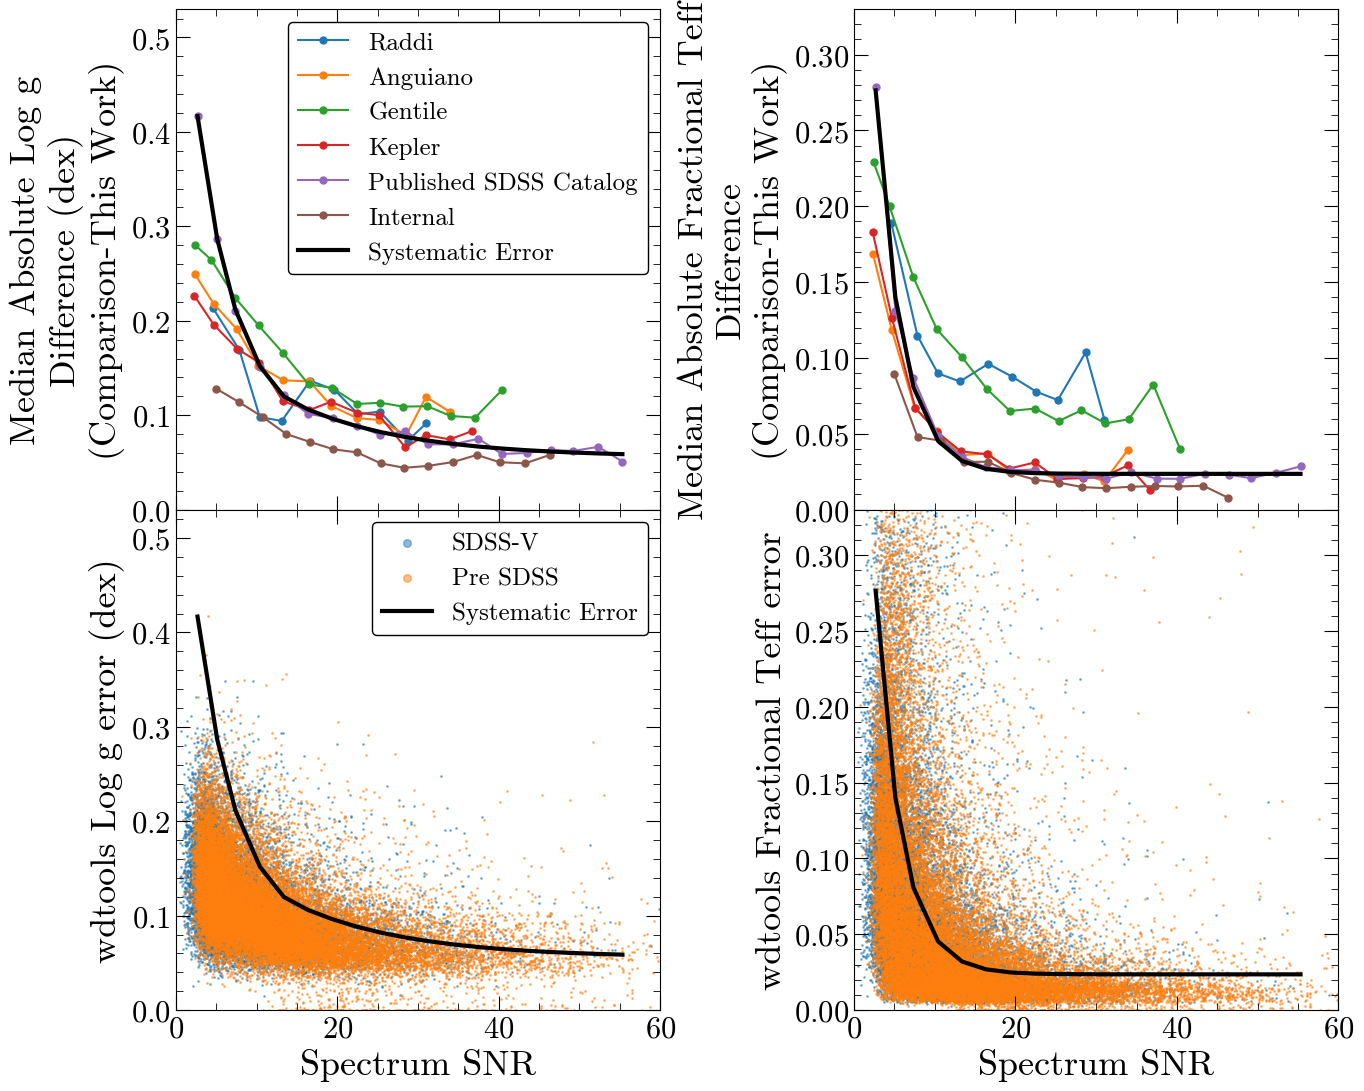

In [47]:
#plot the differences
min_num_obs=20

#model the snr agreement as a piecewise decaying exponential
#fit sdss_dr agreement using bins with bin counts>min_num_obs
def exp(x, a, c, d):
    return a*np.exp(-c*x)+d
name='sdss_dr'
x=mae_sdss_logg_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name]
x1=mae_sdss_logg_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name][:6]
y1=mae_sdss_logg_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name][:6]
x2=mae_sdss_logg_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name][4:]
y2=mae_sdss_logg_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name][4:]
nanmask1=np.logical_not(np.isnan(x1))
nanmask2=np.logical_not(np.isnan(x2))
x1=x1[nanmask1]
y1=y1[nanmask1]
x2=x2[nanmask2]
y2=y2[nanmask2]
popt_logg1, pcov1 = curve_fit(exp, x1, y1, p0=(0.8, 0.2, 0.1))
popt_logg2, pcov2 = curve_fit(exp, x2, y2, p0=(0.8, 0.2, 0.1))
def logg_err(snr_array):
    result=[]
    for snr in snr_array:
        if snr<15:
            result.append(exp(snr, popt_logg1[0], popt_logg1[1], popt_logg1[2]))
        if snr>=15: 
            result.append(exp(snr, popt_logg2[0], popt_logg2[1], popt_logg2[2]))
    return(result)
#print the error function
print('logg sys uncertainty (SNR<15)='+str(np.round(popt_logg1[0],2))+'*exp(-'+str(np.round(popt_logg1[1],2))+'*x)+'+str(np.round(popt_logg1[2],2)))
print('logg sys uncertainty (SNR>=15)='+str(np.round(popt_logg2[0],2))+'*exp(-'+str(np.round(popt_logg2[1],2))+'*x)+'+str(np.round(popt_logg2[2],2)))


#plot
fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize=(15,13),sharex=True)#,sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_logg_snr[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
#plot the overall agreement
ax1.plot(x,logg_err(x),'k',linewidth=3,label='Systematic Error')
ax1.legend()
ax1.set_ylabel("Median Absolute Log g\nDifference (dex)\n(Comparison-This Work)")

#plot the wdtools error as a function of SNR
ax3.scatter(SDSSV_tab['snr'],SDSSV_tab['e_logg_prf_ind'],s=1,alpha=0.5,rasterized=True,label='SDSS-V')
ax3.scatter(eSDSS_tab['snr'],eSDSS_tab['e_logg_prf_ind'],s=1,alpha=0.5,rasterized=True,label='Pre SDSS')
ax3.plot(x,logg_err(x),'k',linewidth=3,label='Systematic Error')
ax3.legend()
ax3.set_ylabel("wdtools Log g error (dex)")
ax3.set_xlabel("Spectrum SNR")
#change the marker size manually
lgnd = ax3.legend(loc='upper right')
lgnd.legend_handles[0]._sizes = [30]
lgnd.legend_handles[1]._sizes = [30]

#repeat for teff

#model the snr agreement as a decaying exponential, fit sdss_dr agreement using bins with bin counts>min_num_obs
name='sdss_dr'
x=mae_sdss_teff_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name]
y=mae_sdss_teff_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name]
nanmask=np.logical_not(np.isnan(x))
x=x[nanmask]
y=y[nanmask]
popt_teff, pcov = curve_fit(exp, x, y,p0=(1,0.5,0.03))
def teff_err(snr_array):
    result=[]
    for snr in snr_array:
        result.append(exp(snr, popt_teff[0], popt_teff[1], popt_teff[2]))
    return(result)
#print the error function
print('teff sys uncertainty='+str(np.round(popt_teff[0],2))+'*exp(-'+str(np.round(popt_teff[1],2))+'*x)+'+str(np.round(popt_teff[2],2)))

#plot
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_snr[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
#plot the overall agreement
ax2.plot(x,teff_err(x),'k',linewidth=3,label='Systematic Error')
ax2.set_ylabel("Median Absolute Fractional Teff\nDifference\n(Comparison-This Work)")

#plot the wdtools error as a function of SNR
ax4.scatter(SDSSV_tab['snr'],SDSSV_tab['e_teff_prf_ind']/SDSSV_tab['teff_prf_ind'],s=1,alpha=0.5,rasterized=True,label='SDSS-V')
ax4.scatter(eSDSS_tab['snr'],eSDSS_tab['e_teff_prf_ind']/eSDSS_tab['teff_prf_ind'],s=1,alpha=0.5,rasterized=True,label='Pre SDSS')
ax4.plot(x,teff_err(x),'k',linewidth=3,label='Systematic Error')
ax4.set_ylabel("wdtools Fractional Teff error")
ax4.set_xlabel("Spectrum SNR")


ax1.set_xlim(0,60)

ax1.set_ylim(0,0.53)
ax3.set_ylim(0,0.53)

ax2.set_ylim(0,0.33)
ax4.set_ylim(0,0.33)

plt.subplots_adjust(hspace=0,wspace=0.4)

plt.savefig('spec_err_snr.pdf', dpi=300)


In [48]:
print(logg_err([0]))
print(logg_err([5]))
print(logg_err([10]))
print(logg_err([20]))
print(logg_err([50]))

[0.656799880044207]
[0.2919066854370266]
[0.15806673565562157]
[0.09456705477544933]
[0.06021630558659164]


In [49]:
print(teff_err([0]))
print(teff_err([5]))
print(teff_err([10]))
print(teff_err([20]))
print(teff_err([50]))

[0.6163823591751646]
[0.1449431010945044]
[0.04843745622952988]
[0.0246383771961612]
[0.02359756338794693]


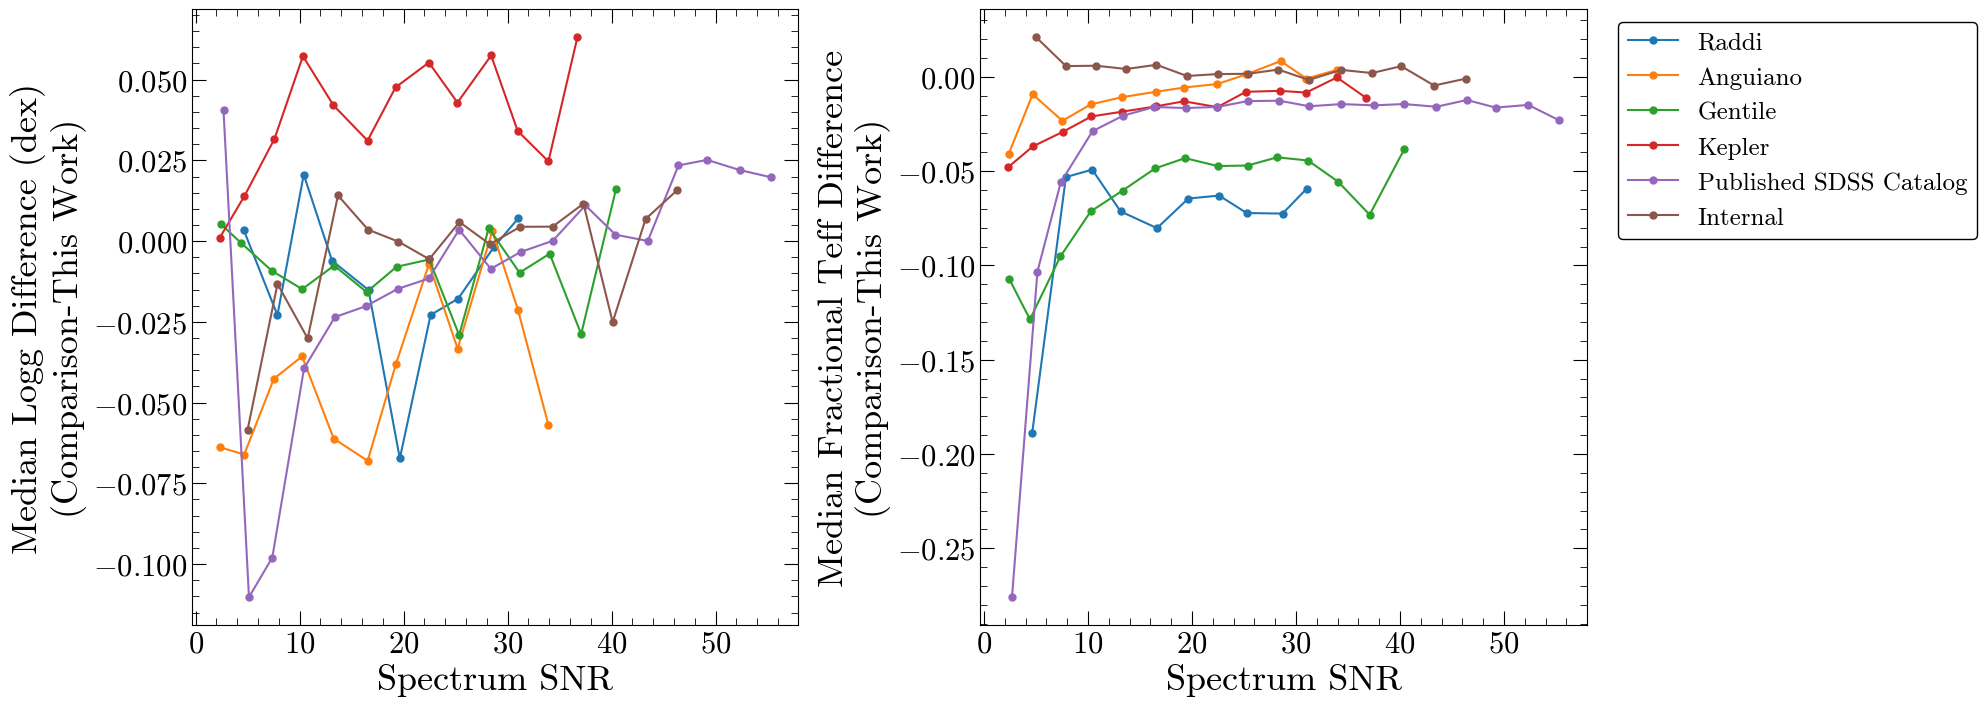

In [50]:
#plot the differences
min_num_obs=20

#plot
fig, (ax1,ax2) =plt.subplots(1,2,figsize=(18,8))
plt.style.use('stefan.mplstyle')
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_logg_snr_med[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
ax1.set_ylabel("Median Logg Difference (dex)\n(Comparison-This Work)")
ax1.set_xlabel("Spectrum SNR")

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_snr_med[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
ax2.legend(bbox_to_anchor=(1.03, 1))
ax2.set_ylabel("Median Fractional Teff Difference\n(Comparison-This Work)")
ax2.set_xlabel("Spectrum SNR")


plt.subplots_adjust(wspace=0.3)

#plt.savefig('rv_err.pdf', dpi=300)


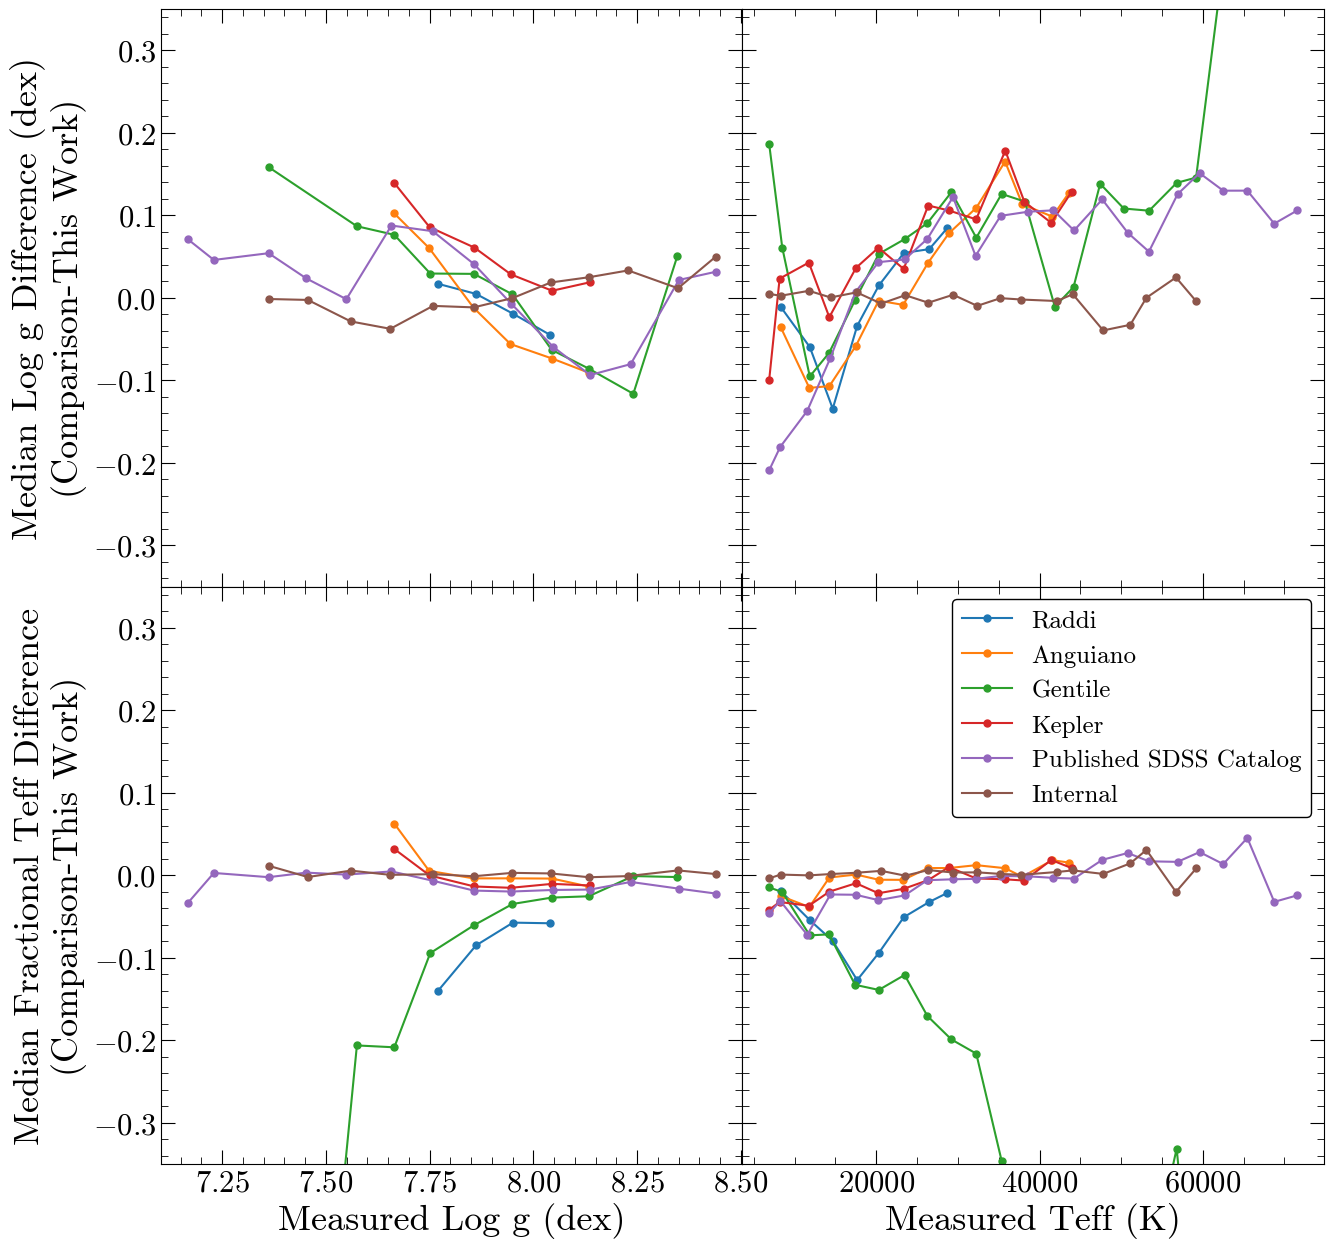

In [51]:
#plot the differences
min_num_obs=20

#plot
fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize=(15,15))
plt.style.use('stefan.mplstyle')
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_logg_logg_med[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
ax1.set_ylabel("Median Log g Difference (dex)\n(Comparison-This Work)")

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_logg_teff_med[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_logg_med[i]
    ax3.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
ax3.set_ylabel("Median Fractional Teff Difference\n(Comparison-This Work)")
ax3.set_xlabel("Measured Log g (dex)")

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_teff_med[i]
    ax4.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
ax4.set_xlabel("Measured Teff (K)")

ax4.legend()

#make y limits consistent
ax1.set_ylim(-0.35,0.35)
ax2.set_ylim(-0.35,0.35)
#hide tick labels
ax2.yaxis.set_ticklabels([])

#make y limits consistent
ax3.set_ylim(-0.35,0.35)
ax4.set_ylim(-0.35,0.35)
#hide tick labels
ax4.yaxis.set_ticklabels([])

#hide xtick labels
ax1.xaxis.set_ticklabels([])
ax2.xaxis.set_ticklabels([])

plt.subplots_adjust(hspace=0,wspace=0)

plt.savefig('spec_err.pdf', dpi=300)


# Calculating Full Error and Weighted Mean Loggs/Teffs

In [53]:
snr_cut=10

#add this systematic error in quadrature to the statistical prf error to get the full error
#for individual exps and coadds
#the calculate the weighted mean logg/teff of all spectra with SNR>10

for j in tqdm(range(SDSSV_num_id_sets)):
    obj_ids=id_SDSSV_dict['set_'+str(j)].astype(int)
    e_teff_prf_ind_full=np.array([])
    e_logg_prf_ind_full=np.array([])
    e_teff_prf_coadd_full=np.array([])
    e_logg_prf_coadd_full=np.array([])
    
    teff_prf_mean=np.array([])
    e_teff_prf_mean=np.array([])
    logg_prf_mean=np.array([])
    e_logg_prf_mean=np.array([])
    
    nexp_mean_teff=np.array([])
    nexp_mean_logg=np.array([])

    for obj_id in obj_ids:
        table=SDSSV_dict['set_'+str(j)].query('gaia_dr3_source_id==@obj_id')
        #reset the indices
        indices=np.arange(0,len(table))
        table.set_index(indices,inplace=True)
        #get the parameters from the table
        ind_snrs=np.array(table['snr'].to_list())
        coadd_snrs=np.array(table['snr_coadd'].to_list())
        ind_teffs=np.array(table['teff_prf_ind'].to_list())
        e_ind_teffs=np.array(table['e_teff_prf_ind'].to_list())
        ind_loggs=np.array(table['logg_prf_ind'].to_list())
        e_ind_loggs=np.array(table['e_logg_prf_ind'].to_list())
        coadd_teffs=np.array(table['teff_prf_coadd'].to_list())
        e_coadd_teffs=np.array(table['e_teff_prf_coadd'].to_list())
        coadd_loggs=np.array(table['logg_prf_coadd'].to_list())
        e_coadd_loggs=np.array(table['e_logg_prf_coadd'].to_list())
       
        #use the fit to calculate the systematic teff/logg errors
        sys_teff_err_ind=teff_err(ind_snrs)*ind_teffs #multiply fractional uncertainty by teff
        sys_teff_err_coadd=teff_err(coadd_snrs)*coadd_teffs #multiply fractional uncertainty by teff
        sys_logg_err_ind=logg_err(ind_snrs)
        sys_logg_err_coadd=logg_err(coadd_snrs)
        
        #add this in quadrature to get the full error
        e_ind_teffs_full=np.sqrt(e_ind_teffs**2+np.full(len(e_ind_teffs),sys_teff_err_ind)**2)
        e_ind_loggs_full=np.sqrt(e_ind_loggs**2+np.full(len(e_ind_loggs),sys_logg_err_ind)**2)
        e_coadd_teffs_full=np.sqrt(e_coadd_teffs**2+np.full(len(e_coadd_teffs),sys_teff_err_coadd)**2)
        e_coadd_loggs_full=np.sqrt(e_coadd_loggs**2+np.full(len(e_coadd_loggs),sys_logg_err_coadd)**2)
        
        #save these parameters
        e_teff_prf_ind_full=np.append(e_teff_prf_ind_full,e_ind_teffs_full)
        e_logg_prf_ind_full=np.append(e_logg_prf_ind_full,e_ind_loggs_full)
        e_teff_prf_coadd_full=np.append(e_teff_prf_coadd_full,e_coadd_teffs_full)
        e_logg_prf_coadd_full=np.append(e_logg_prf_coadd_full,e_coadd_loggs_full)
        
        #take weighted mean logg/teff of spectra with SNR>snr_cut using the full error
        #check also that the fit did not fail by requiring e_ind_teff/logg>0
        good_teffs=[]
        e_good_teffs=[]
        good_loggs=[]
        e_good_loggs=[]
        for i in range(len(ind_snrs)):
            if ind_snrs[i]>snr_cut and e_ind_teffs_full[i]>0:
                good_teffs.append(ind_teffs[i])
                e_good_teffs.append(e_ind_teffs_full[i])
                
            if ind_snrs[i]>snr_cut and e_ind_loggs_full[i]>0:
                good_loggs.append(ind_loggs[i])
                e_good_loggs.append(e_ind_loggs_full[i])
                
        nhisnr_teff=len(good_teffs) #count number of spectra averaged
        nhisnr_logg=len(good_loggs)
        
        if nhisnr_teff>0:
            #calculate weights
            weights=(1/np.array(e_good_teffs))**2
            #calculate mean RV and error on mean
            mean=np.average(good_teffs,weights=weights)
            e_mean=1/np.sqrt(np.sum(weights))
        else:
            mean=np.nan
            e_mean=np.nan
        #save these parameters
        teff_prf_mean=np.append(teff_prf_mean,np.full(len(ind_teffs),mean))
        e_teff_prf_mean=np.append(e_teff_prf_mean,np.full(len(ind_teffs),e_mean))
        nexp_mean_teff=np.append(nexp_mean_teff,np.full(len(ind_teffs),nhisnr_teff))
        
        if nhisnr_logg>0:
            #calculate weights
            weights=(1/np.array(e_good_loggs))**2
            #calculate mean RV and error on mean
            mean=np.average(good_loggs,weights=weights)
            e_mean=1/np.sqrt(np.sum(weights))
        else:
            mean=np.nan
            e_mean=np.nan
        #save these parameters
        logg_prf_mean=np.append(logg_prf_mean,np.full(len(ind_loggs),mean))
        e_logg_prf_mean=np.append(e_logg_prf_mean,np.full(len(ind_loggs),e_mean))
        nexp_mean_logg=np.append(nexp_mean_logg,np.full(len(ind_loggs),nhisnr_logg))

    #add everything to the table
    SDSSV_dict['set_'+str(j)]['e_teff_prf_ind_full']=e_teff_prf_ind_full.flatten()
    SDSSV_dict['set_'+str(j)]['e_logg_prf_ind_full']=e_logg_prf_ind_full.flatten()
    SDSSV_dict['set_'+str(j)]['e_teff_prf_coadd_full']=e_teff_prf_coadd_full.flatten()
    SDSSV_dict['set_'+str(j)]['e_logg_prf_coadd_full']=e_logg_prf_coadd_full.flatten()
    SDSSV_dict['set_'+str(j)]['teff_prf_mean']=teff_prf_mean.flatten()
    SDSSV_dict['set_'+str(j)]['e_teff_prf_mean']=e_teff_prf_mean.flatten()
    SDSSV_dict['set_'+str(j)]['logg_prf_mean']=logg_prf_mean.flatten()
    SDSSV_dict['set_'+str(j)]['e_logg_prf_mean']=e_logg_prf_mean.flatten()
    SDSSV_dict['set_'+str(j)]['nspec_mean_teff']=nexp_mean_teff.flatten()
    SDSSV_dict['set_'+str(j)]['nspec_mean_logg']=nexp_mean_logg.flatten()
    
    #save as a .csv
    SDSSV_dict['set_'+str(j)].to_csv('csv/SDSSV_short_sets/set_'+str(j)+'.csv',index=False)
    
    #save to back up
    SDSSV_dict['set_'+str(j)].to_csv('csv/SDSSV_short_sets/set_'+str(j)+'_nb04.csv',index=False)

100%|███████████████████████████████████████████| 22/22 [00:14<00:00,  1.47it/s]


In [54]:
snr_cut=10

#add this systematic error in quadrature to the statistical prf error to get the full error
#for individual exps and coadds
#the calculate the weighted mean logg/teff of all spectra with SNR>10

for j in tqdm(range(eSDSS_num_id_sets)):
    obj_ids=id_eSDSS_dict['set_'+str(j)].astype(int)
    e_teff_prf_ind_full=np.array([])
    e_logg_prf_ind_full=np.array([])
    e_teff_prf_coadd_full=np.array([])
    e_logg_prf_coadd_full=np.array([])
    
    teff_prf_mean=np.array([])
    e_teff_prf_mean=np.array([])
    logg_prf_mean=np.array([])
    e_logg_prf_mean=np.array([])
    
    nexp_mean_teff=np.array([])
    nexp_mean_logg=np.array([])

    for obj_id in obj_ids:
        table=eSDSS_dict['set_'+str(j)].query('gaia_dr3_source_id==@obj_id')
        #reset the indices
        indices=np.arange(0,len(table))
        table.set_index(indices,inplace=True)
        #get the parameters from the table
        ind_snrs=np.array(table['snr'].to_list())
        coadd_snrs=np.array(table['snr_coadd'].to_list())
        ind_teffs=np.array(table['teff_prf_ind'].to_list())
        e_ind_teffs=np.array(table['e_teff_prf_ind'].to_list())
        ind_loggs=np.array(table['logg_prf_ind'].to_list())
        e_ind_loggs=np.array(table['e_logg_prf_ind'].to_list())
        coadd_teffs=np.array(table['teff_prf_coadd'].to_list())
        e_coadd_teffs=np.array(table['e_teff_prf_coadd'].to_list())
        coadd_loggs=np.array(table['logg_prf_coadd'].to_list())
        e_coadd_loggs=np.array(table['e_logg_prf_coadd'].to_list())
       
        #use the fit to calculate the systematic teff/logg errors
        sys_teff_err_ind=teff_err(ind_snrs)
        sys_teff_err_coadd=teff_err(coadd_snrs)
        sys_logg_err_ind=logg_err(ind_snrs)
        sys_logg_err_coadd=logg_err(coadd_snrs)
        
        #add this in quadrature to get the full error
        e_ind_teffs_full=np.sqrt(e_ind_teffs**2+np.full(len(e_ind_teffs),sys_teff_err_ind)**2)
        e_ind_loggs_full=np.sqrt(e_ind_loggs**2+np.full(len(e_ind_loggs),sys_logg_err_ind)**2)
        e_coadd_teffs_full=np.sqrt(e_coadd_teffs**2+np.full(len(e_coadd_teffs),sys_teff_err_coadd)**2)
        e_coadd_loggs_full=np.sqrt(e_coadd_loggs**2+np.full(len(e_coadd_loggs),sys_logg_err_coadd)**2)
        
        #save these parameters
        e_teff_prf_ind_full=np.append(e_teff_prf_ind_full,e_ind_teffs_full)
        e_logg_prf_ind_full=np.append(e_logg_prf_ind_full,e_ind_loggs_full)
        e_teff_prf_coadd_full=np.append(e_teff_prf_coadd_full,e_coadd_teffs_full)
        e_logg_prf_coadd_full=np.append(e_logg_prf_coadd_full,e_coadd_loggs_full)
        
        #take weighted mean logg/teff of spectra with SNR>snr_cut using the full error
        #check also that the fit did not fail by requiring e_ind_teff/logg>0
        good_teffs=[]
        e_good_teffs=[]
        good_loggs=[]
        e_good_loggs=[]
        for i in range(len(ind_snrs)):
            if ind_snrs[i]>snr_cut and e_ind_teffs_full[i]>0:
                good_teffs.append(ind_teffs[i])
                e_good_teffs.append(e_ind_teffs_full[i])
                
            if ind_snrs[i]>snr_cut and e_ind_loggs_full[i]>0:
                good_loggs.append(ind_loggs[i])
                e_good_loggs.append(e_ind_loggs_full[i])
                
        nhisnr_teff=len(good_teffs) #count number of spectra averaged
        nhisnr_logg=len(good_loggs)
        
        if nhisnr_teff>0:
            #calculate weights
            weights=(1/np.array(e_good_teffs))**2
            #calculate mean RV and error on mean
            mean=np.average(good_teffs,weights=weights)
            e_mean=1/np.sqrt(np.sum(weights))
        else:
            mean=np.nan
            e_mean=np.nan
        #save these parameters
        teff_prf_mean=np.append(teff_prf_mean,np.full(len(ind_teffs),mean))
        e_teff_prf_mean=np.append(e_teff_prf_mean,np.full(len(ind_teffs),e_mean))
        nexp_mean_teff=np.append(nexp_mean_teff,np.full(len(ind_teffs),nhisnr_teff))
        
        if nhisnr_logg>0:
            #calculate weights
            weights=(1/np.array(e_good_loggs))**2
            #calculate mean RV and error on mean
            mean=np.average(good_loggs,weights=weights)
            e_mean=1/np.sqrt(np.sum(weights))
        else:
            mean=np.nan
            e_mean=np.nan
        #save these parameters
        logg_prf_mean=np.append(logg_prf_mean,np.full(len(ind_loggs),mean))
        e_logg_prf_mean=np.append(e_logg_prf_mean,np.full(len(ind_loggs),e_mean))
        nexp_mean_logg=np.append(nexp_mean_logg,np.full(len(ind_loggs),nhisnr_logg))

    #add everything to the table
    eSDSS_dict['set_'+str(j)]['e_teff_prf_ind_full']=e_teff_prf_ind_full.flatten()
    eSDSS_dict['set_'+str(j)]['e_logg_prf_ind_full']=e_logg_prf_ind_full.flatten()
    eSDSS_dict['set_'+str(j)]['e_teff_prf_coadd_full']=e_teff_prf_coadd_full.flatten()
    eSDSS_dict['set_'+str(j)]['e_logg_prf_coadd_full']=e_logg_prf_coadd_full.flatten()
    eSDSS_dict['set_'+str(j)]['teff_prf_mean']=teff_prf_mean.flatten()
    eSDSS_dict['set_'+str(j)]['e_teff_prf_mean']=e_teff_prf_mean.flatten()
    eSDSS_dict['set_'+str(j)]['logg_prf_mean']=logg_prf_mean.flatten()
    eSDSS_dict['set_'+str(j)]['e_logg_prf_mean']=e_logg_prf_mean.flatten()
    eSDSS_dict['set_'+str(j)]['nspec_mean_teff']=nexp_mean_teff.flatten()
    eSDSS_dict['set_'+str(j)]['nspec_mean_logg']=nexp_mean_logg.flatten()
    
    #save as a .csv
    eSDSS_dict['set_'+str(j)].to_csv('csv/eSDSS_short_sets/set_'+str(j)+'.csv',index=False)
    
    #save to back up
    eSDSS_dict['set_'+str(j)].to_csv('csv/eSDSS_short_sets/set_'+str(j)+'_nb04.csv',index=False)

100%|███████████████████████████████████████████| 49/49 [00:28<00:00,  1.74it/s]


### Combine all subsets together and save

In [55]:
#combine all the dataframes together
SDSSV_tab=pd.concat([SDSSV_dict['set_0'], SDSSV_dict['set_1']], ignore_index=True)
for i in tqdm(range(SDSSV_num_id_sets-2)):
    SDSSV_tab=pd.concat([SDSSV_tab, SDSSV_dict['set_'+str(i+2)]], ignore_index=True)
#reset the indices
indices=np.arange(0,len(SDSSV_tab))
SDSSV_tab.set_index(indices,inplace=True)
#save as a .csv
SDSSV_tab.to_csv('csv/SDSSV_DA_df.csv',index=False)
#save to back up
SDSSV_tab.to_csv('csv/SDSSV_DA_df_nb04.csv',index=False)


100%|██████████████████████████████████████████| 20/20 [00:00<00:00, 260.85it/s]


In [56]:
#combine all the dataframes together
eSDSS_tab=pd.concat([eSDSS_dict['set_0'], eSDSS_dict['set_1']], ignore_index=True)
for i in tqdm(range(eSDSS_num_id_sets-2)):
    eSDSS_tab=pd.concat([eSDSS_tab, eSDSS_dict['set_'+str(i+2)]], ignore_index=True)
#reset the indices
indices=np.arange(0,len(eSDSS_tab))
eSDSS_tab.set_index(indices,inplace=True)
#save as a .csv
eSDSS_tab.to_csv('csv/eSDSS_DA_df.csv',index=False)
#save to back up
eSDSS_tab.to_csv('csv/eSDSS_DA_df_nb04.csv',index=False)


100%|██████████████████████████████████████████| 47/47 [00:00<00:00, 421.06it/s]


# SDSS-V Coadd Teffs/Loggs vs Individual and Mean vs Individual and Coadd  vs Mean 


In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_coadd>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_coadd','teff','K',statx=0,staty=80000,statdy=4000,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_mean_teff>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_mean','teff','K',statx=0,staty=80000,statdy=4000,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_mean_teff>1 & nspec_coadd>1 & snr_coadd>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_coadd','prf_mean','teff','K',statx=0,staty=80000,statdy=4000,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_coadd>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_coadd','logg','dex',statx=7.0,staty=8.75,statdy=0.1,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_mean_teff>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_mean','logg','dex',statx=7.0,staty=8.75,statdy=0.1,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_mean_teff>1 & nspec_coadd>1 & snr_coadd>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_coadd','prf_mean','logg','dex',statx=7.3,staty=8.65,statdy=0.1,
                   siegel=True,plthist=True,savefig=False)

# eSDSS Coadd Teffs/Loggs vs Individual and Mean vs Individual and Coadd  vs Mean 

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_coadd>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['teff_prf_coadd'].isna()]
wd_table=wd_table[~wd_table['teff_prf_ind'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_coadd','teff','K',statx=0,staty=75000,statdy=4000,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_mean_teff>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['teff_prf_mean'].isna()]
wd_table=wd_table[~wd_table['teff_prf_ind'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_mean','teff','K',statx=0,staty=75000,statdy=4000,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_mean_teff>1 & nspec_coadd>1 & snr_coadd>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['teff_prf_mean'].isna()]
wd_table=wd_table[~wd_table['teff_prf_coadd'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_coadd','prf_mean','teff','K',statx=3000,staty=75000,statdy=4000,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_coadd>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['logg_prf_coadd'].isna()]
wd_table=wd_table[~wd_table['logg_prf_ind'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_coadd','logg','dex',statx=7.0,staty=8.75,statdy=0.1,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_mean_teff>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['logg_prf_mean'].isna()]
wd_table=wd_table[~wd_table['logg_prf_ind'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_ind','prf_mean','logg','dex',statx=7.0,staty=8.75,statdy=0.1,
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_mean_teff>1 & nspec_coadd>1 & snr_coadd>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['logg_prf_mean'].isna()]
wd_table=wd_table[~wd_table['logg_prf_coadd'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'prf_coadd','prf_mean','logg','dex',statx=7.0,staty=8.75,statdy=0.1,
                   siegel=True,plthist=True,savefig=False)